# Powertrain

Electric machines, turboshafts, gearboxes, rotors as power sinks, the topology that connects them, the
electrical layer, redundancy and thermal management. Section 1 is the current reference; the rest verifies each
component model on its own.

In [1]:
import sys
import time
import warnings
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
for path in (repo_root / "src", repo_root):     # this checkout's package even if another one is installed
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
warnings.filterwarnings("ignore", category=FutureWarning)

import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

check_log = []


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua, yellow = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

## 1. The reference powertrain

In [2]:
# The current reference: every model at its highest fidelity (about 10 minutes from cold).
from examples.halo_sizing import (HaloAssumptions as RefAssumptions, HaloRequirements as RefRequirements,
                                  soc_emergency_floor, soc_minimum, solve_halo_sizing as solve_reference)
t0 = time.time()
ref = solve_reference()
print(f"reference: {ref.mass_takeoff_kg:,.0f} kg = {ref.mass_takeoff_kg / u.lbm:,.0f} lb, "
      f"empty {ref.mass_empty_kg:,.0f} kg, fuel {ref.mass_fuel_kg:,.0f} kg ({(time.time() - t0) / 60:.1f} min)")
check("reference closes with every margin satisfied", ref.min_margin > -1e-6)
check("reference take-off weight 15,179 lb (+- 20)", abs(ref.mass_takeoff_kg / u.lbm - 15179) < 20)

CasADi - 2026-10-06 02:02:11 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 608, col 0).") [.../casadi/core/oracle_function.cpp:408]


reference: 6,885 kg = 15,179 lb, empty 5,049 kg, fuel 936 kg (10.1 min)
PASS  reference closes with every margin satisfied
PASS  reference take-off weight 15,179 lb (+- 20)


In [3]:
units = ref.machine_units
print("machine units:", {k: f"{v[1]} units" for k, v in units.items()}, f"; lanes per rotor {ref.count_lanes_motor}")
for name, kg in ref.powertrain_masses_kg:
    print(f"  {name:<20}{kg:8.1f} kg")
print(f"\n{'failure case':<34}{'SOC end':>8}{'lanes':>6}{'strings':>8}{'gens':>5}{'T/Tmax':>8}{'T motor C':>10}")
for f in ref.failure_cases:
    temperature = f["temperature_end_motor_C"]
    print(f"{f['label']:<34}{f['soc_end']:8.3f}{f['count_lanes_active']:6d}{f['count_strings_active']:8d}"
          f"{f['count_generators_active']:5d}{f['torque_lane_to_max']:8.2f}"
          f"{'' if temperature is None else f'{temperature:10.1f}'}")
check("every failure case ends above the 0.10 emergency SOC",
      all(f["soc_end"] >= soc_emergency_floor - 1e-6 for f in ref.failure_cases))
check("no lane exceeds its torque limit in a failure", all(f["torque_lane_to_max"] <= 1 + 1e-6 for f in ref.failure_cases))

machine units: {'motor': '2 units', 'generator': '3 units'} ; lanes per rotor 2
  turboshaft             421.7 kg
  generator              281.7 kg
  battery                475.1 kg
  motor                  425.6 kg
  gearbox                292.4 kg
  propulsor              674.9 kg
  generator_gearbox      144.2 kg
  protection_string        4.5 kg
  protection_bus_tie       9.1 kg
  cable_bus_tie           14.9 kg
  heat_exchanger         126.9 kg

failure case                       SOC end lanes strings gens  T/Tmax T motor C
bus-out hover                        0.208     1       2    2    1.00     100.9
string-out hover                     0.209     2       1    2    0.52      83.4
PASS  every failure case ends above the 0.10 emergency SOC
PASS  no lane exceeds its torque limit in a failure


In [4]:
hx, rows = ref.heat_exchanger, ref.thermal_trace
print(f"heat exchanger {hx['power_rated_W'] / 1e3:.0f} kW rated, {hx['mass_kg']:.0f} kg")
print(f"{'point':<26}{'Q kW':>7}{'T motor':>9}{'T gen':>7}{'T batt':>8}")
for row in rows:
    t = row["temperatures_end_C"]
    print(f"{row['label']:<26}{row['power_heat_equivalent_W'] / 1e3:7.1f}{t['motor']:9.1f}{t['generator']:7.1f}"
          f"{t['battery']:8.1f}")
check("the exchanger rating covers every point",
      max(r["power_heat_equivalent_W"] for r in rows) <= hx["power_rated_W"] * (1 + 1e-6))
check("every machine within 150 C and the pack within 60 C",
      all(r["temperatures_end_C"][n] <= 150 + 1e-3 for r in rows for n in ("motor", "generator"))
      and all(r["temperatures_end_C"]["battery"] <= 60 + 1e-3 for r in rows))

heat exchanger 127 kW rated, 127 kg
point                        Q kW  T motor  T gen  T batt
take-off hover               31.8     73.4   79.9    25.1
climb                        77.8    114.3  103.9    25.4
cruise 1/4                   42.2     90.6   93.3    25.0
cruise 2/4                   40.9     89.7   92.3    25.0
cruise 3/4                   39.7     88.8   91.3    25.0
cruise 4/4                   38.8     88.0   90.6    25.0
reserve loiter               37.4     87.5   89.1    25.0
descent                      30.1     75.8   82.9    25.0
landing hover                50.5     82.7   89.8    25.3
engine-out hover 1/3         48.5     77.1   87.1    30.2
engine-out hover 2/3         72.4     80.3   93.4    35.0
engine-out hover 3/3         98.9     83.3   98.8    40.7
bus-out hover 1/3            36.9     83.5   83.7    25.9
bus-out hover 2/3            48.0     92.7   86.5    27.0
bus-out hover 3/3            58.8    100.9   88.7    28.3
string-out hover 1/3         40.8   

## 2. Components: motor, generator, turboshaft, gearbox, rotor

*From `tier1_powertrain_components/powertrain_verification.ipynb`.*

In [5]:
import sys
from pathlib import Path

# Make `examples` importable alongside the installed package.
repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import casadi as cas
import matplotlib.pyplot as plt
from aerosandbox.library.propulsion_propeller import propeller_shaft_power_from_thrust

from aircraft_closure.powertrain.components.motor import Motor, SimpleMotorLossModel
from aircraft_closure.powertrain.components.generator import Generator
from aircraft_closure.powertrain.components.battery import Battery
from aircraft_closure.powertrain.components.turboshaft import SimpleTurboshaft
from aircraft_closure.powertrain.components.gearbox import Gearbox
from aircraft_closure.powertrain.components.propulsor import ActuatorDiskPropulsor
from examples.series_hybrid_point_explicit import solve_reference_point

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True})

check_log = globals().get("check_log", [])

def check(name, condition):
    passed = bool(condition)
    check_log.append((name, passed))
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")

def close(a, b, rel=1e-9, abs_=1e-9):
    return np.all(np.abs(np.asarray(a) - np.asarray(b)) <= abs_ + rel * np.abs(np.asarray(b)))

### 1. Motor

Motoring quadrant only. Shaft power is $P_s = \omega\,Q$; the simple loss model is
$P_{loss} = k_Q Q^2 + k_\omega \omega^2$; electrical input is $P_e = P_s + P_{loss}$
and current is $I = P_e / V$.

In [6]:
simple_losses = SimpleMotorLossModel()
motor = Motor(loss_model=simple_losses)
r = motor.evaluate(400, 200, 800)
print(r)
print(f"efficiency = {r.power_shaft_W / r.power_electric_W:.4f}")

check("motor: P_shaft = speed * torque", r.power_shaft_W == 400 * 200)
check("motor: P_elec = P_shaft + P_loss", close(r.power_electric_W, r.power_shaft_W + r.power_loss_W))
check("motor: I * V = P_elec", close(r.current_A * 800, r.power_electric_W))
check("motor: losses > 0", r.power_loss_W > 0)
check("motor: lossless model gives P_elec = P_shaft",
      Motor(loss_model=SimpleMotorLossModel(0, 0)).evaluate(400, 200, 800).power_electric_W == 80000)
check("motor: zero demand -> zero electrical power", motor.evaluate(0, 0, 800).power_electric_W == 0)
check("motor: halving voltage doubles current",
      close(motor.evaluate(400, 200, 400).current_A, 2 * r.current_A))
check("motor: mass = rated power / specific power", motor.get_mass() == 100000 / 5000)

MotorResult(power_shaft_W=80000, power_electric_W=80960.0, current_A=101.2, power_loss_W=960.0)
efficiency = 0.9881
[PASS] motor: P_shaft = speed * torque
[PASS] motor: P_elec = P_shaft + P_loss
[PASS] motor: I * V = P_elec
[PASS] motor: losses > 0
[PASS] motor: lossless model gives P_elec = P_shaft
[PASS] motor: zero demand -> zero electrical power
[PASS] motor: halving voltage doubles current
[PASS] motor: mass = rated power / specific power


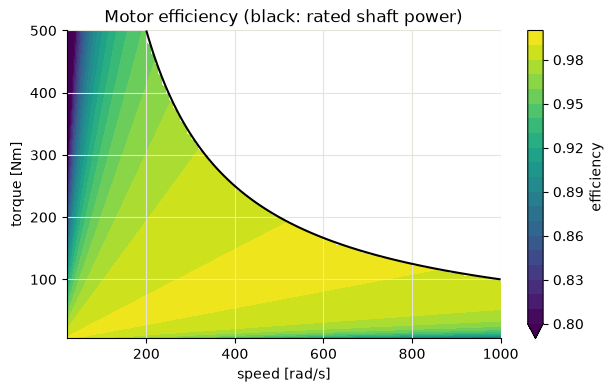

[PASS] motor: minimum loss at fixed power where torque and speed losses balance


In [7]:
# Efficiency map over the motoring envelope (numeric arrays pass straight through).
speed_rad_s, torque_Nm = np.meshgrid(np.linspace(20, motor.max_speed_rad_s, 120),
                                     np.linspace(5, motor.max_torque_Nm, 120))
grid = motor.evaluate(speed_rad_s, torque_Nm, 800)
efficiency = grid.power_shaft_W / grid.power_electric_W
in_rating = grid.power_shaft_W <= motor.power_rated_W

fig, ax = plt.subplots()
cs = ax.contourf(speed_rad_s, torque_Nm, np.where(in_rating, efficiency, np.nan),
                 levels=np.linspace(0.80, 1.0, 21), cmap="viridis", extend="min")
ax.contour(speed_rad_s, torque_Nm, grid.power_shaft_W, levels=[motor.power_rated_W], colors="k")
fig.colorbar(cs, label="efficiency")
ax.set(xlabel="speed [rad/s]", ylabel="torque [Nm]",
       title="Motor efficiency (black: rated shaft power)")
plt.show()

# With k_Q Q^2 + k_w w^2 losses at fixed power, peak efficiency is where the two terms are equal.
k = motor.loss_model
power_W = 50000
speed_opt_rad_s = (k.torque_loss_W_Nm2 * power_W**2 / k.speed_loss_W_s2_rad2) ** 0.25
speeds = np.linspace(100, 1000, 2001)
loss_W = motor.evaluate(speeds, power_W / speeds, 800).power_loss_W
check("motor: minimum loss at fixed power where torque and speed losses balance",
      abs(speeds[np.argmin(loss_W)] - speed_opt_rad_s) < 1.0)

### 2. Generator

Generating quadrant: shaft input supplies electrical output plus losses,
$P_e = P_s - P_{loss}$. Current is positive *out of* the machine. Shares the
motor loss model and `MotorLimits`.

GeneratorResult(power_shaft_W=80000, power_electric_W=79040.0, current_A=98.8, power_loss_W=960.0)
[PASS] generator: P_shaft = P_elec + P_loss
[PASS] generator: output current positive
[PASS] generator: I * V = P_elec
[PASS] generator: zero shaft -> zero output
[PASS] generator: more torque -> more output
[PASS] motor/generator: same loss at same operating point
[PASS] generator: mass = rated power / specific power


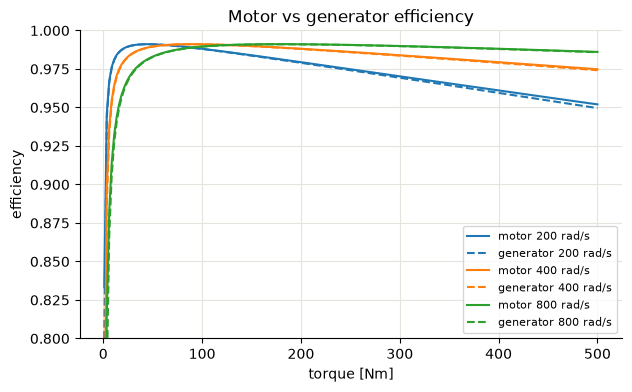

In [8]:
generator = Generator(loss_model=simple_losses)
g = generator.evaluate(400, 200, 800)
print(g)

check("generator: P_shaft = P_elec + P_loss", close(g.power_shaft_W, g.power_electric_W + g.power_loss_W))
check("generator: output current positive", g.current_A > 0)
check("generator: I * V = P_elec", close(g.current_A * 800, g.power_electric_W))
check("generator: zero shaft -> zero output", generator.evaluate(0, 0, 800).power_electric_W == 0)
check("generator: more torque -> more output",
      generator.evaluate(400, 200, 800).power_electric_W > generator.evaluate(400, 100, 800).power_electric_W)
check("motor/generator: same loss at same operating point",
      close(g.power_loss_W, motor.evaluate(400, 200, 800).power_loss_W))
check("generator: mass = rated power / specific power", generator.get_mass() == 100000 / 4000)

torque = np.linspace(1, 500, 200)
fig, ax = plt.subplots()
for speed in (200, 400, 800):
    res_m = motor.evaluate(speed, torque, 800)
    res_g = generator.evaluate(speed, torque, 800)
    line, = ax.plot(torque, res_m.power_shaft_W / res_m.power_electric_W, label=f"motor {speed} rad/s")
    ax.plot(torque, res_g.power_electric_W / res_g.power_shaft_W, "--", color=line.get_color(),
            label=f"generator {speed} rad/s")
ax.set(xlabel="torque [Nm]", ylabel="efficiency", ylim=(0.8, 1.0), title="Motor vs generator efficiency")
ax.legend(fontsize=8)
plt.show()

### 4. Turboshaft

Constant thermal efficiency, no altitude lapse or idle:
$\dot m_f = P_s / (\eta_{th}\,\text{LHV})$.

TurboshaftResult(power_shaft_W=100000, fuel_flow_kg_s=0.007751937984496125, power_loss_W=233333.33333333337)
BSFC = 279.1 g/kWh
[PASS] turboshaft: fuel energy * efficiency = shaft power
[PASS] turboshaft: loss + shaft = fuel power
[PASS] turboshaft: zero power -> zero fuel
[PASS] turboshaft: higher efficiency -> less fuel
[PASS] turboshaft: mass = rated power / specific power


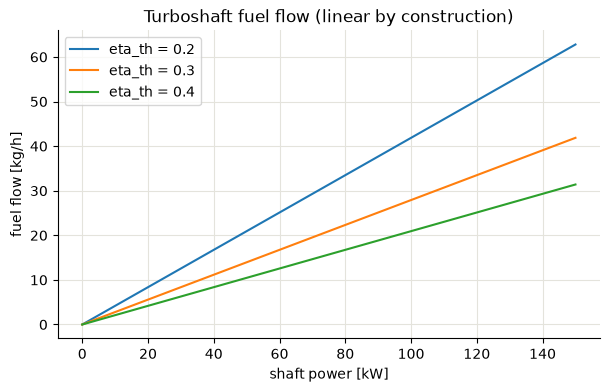

In [9]:
engine = SimpleTurboshaft()
e = engine.evaluate(100000)
print(e)
print(f"BSFC = {e.fuel_flow_kg_s / 100000 * 3.6e9:.1f} g/kWh")

check("turboshaft: fuel energy * efficiency = shaft power",
      close(e.fuel_flow_kg_s * engine.fuel_lower_heating_value_J_kg * engine.thermal_efficiency, 100000))
check("turboshaft: loss + shaft = fuel power",
      close(e.power_loss_W + e.power_shaft_W, e.fuel_flow_kg_s * engine.fuel_lower_heating_value_J_kg))
check("turboshaft: zero power -> zero fuel", engine.evaluate(0).fuel_flow_kg_s == 0)
check("turboshaft: higher efficiency -> less fuel",
      SimpleTurboshaft(thermal_efficiency=0.4).evaluate(100000).fuel_flow_kg_s < e.fuel_flow_kg_s)
check("turboshaft: mass = rated power / specific power", engine.get_mass() == 75)

power_W = np.linspace(0, engine.power_rated_W, 50)
fig, ax = plt.subplots()
for eta in (0.2, 0.3, 0.4):
    ax.plot(power_W / 1e3, SimpleTurboshaft(thermal_efficiency=eta).evaluate(power_W).fuel_flow_kg_s * 3600,
            label=f"eta_th = {eta}")
ax.set(xlabel="shaft power [kW]", ylabel="fuel flow [kg/h]", title="Turboshaft fuel flow (linear by construction)")
ax.legend()
plt.show()

### 5. Gearbox

`reduction_ratio` = input speed / output speed. Loss is taken from torque so
$P_{out} = \omega_{out} Q_{out}$ holds exactly.

In [10]:
gear = Gearbox()
gb = gear.evaluate(400, 200)
print(gb)

check("gearbox: output speed = input / ratio", gb.speed_output_rad_s == 100)
check("gearbox: output torque = input * ratio * efficiency", close(gb.torque_output_Nm, 200 * 4 * 0.97))
check("gearbox: P_out = speed_out * torque_out", close(gb.power_output_W, gb.speed_output_rad_s * gb.torque_output_Nm))
check("gearbox: P_in = P_out + P_loss", close(gb.power_input_W, gb.power_output_W + gb.power_loss_W))
t = Gearbox(reduction_ratio=1, efficiency=1).evaluate(400, 200)
check("gearbox: 1:1 lossless is transparent",
      t.speed_output_rad_s == 400 and t.torque_output_Nm == 200 and t.power_loss_W == 0)
check("gearbox: lower efficiency -> more loss",
      Gearbox(efficiency=0.9).evaluate(400, 200).power_loss_W > Gearbox(efficiency=0.99).evaluate(400, 200).power_loss_W)
check("gearbox: mass = rated power / specific power", gear.get_mass() == 10)

GearboxResult(speed_output_rad_s=100.0, torque_output_Nm=776.0, power_input_W=80000, power_output_W=77600.0, power_loss_W=2400.0000000000023)
[PASS] gearbox: output speed = input / ratio
[PASS] gearbox: output torque = input * ratio * efficiency
[PASS] gearbox: P_out = speed_out * torque_out
[PASS] gearbox: P_in = P_out + P_loss
[PASS] gearbox: 1:1 lossless is transparent
[PASS] gearbox: lower efficiency -> more loss
[PASS] gearbox: mass = rated power / specific power


### 6. Actuator-disk propulsor

Axial momentum theory, normal working state. Two modes:

* **Thrust mode** — closed-form induced velocity (rationalized root), returns shaft power.
* **Power mode** — caller supplies shaft power *and* induced velocity; the component
  returns `power_residual_W`, which the caller drives to zero in `asb.Opti`.

In [11]:
atmosphere = asb.Atmosphere(altitude=0)
rho_kg_m3 = atmosphere.density()
rotor = ActuatorDiskPropulsor()
h = rotor.evaluate(0, atmosphere, thrust_N=5000)
print(h)

ideal_rotor = ActuatorDiskPropulsor(coefficient_of_performance=1)
check("propulsor: ideal hover P = T^1.5 / sqrt(2 rho A)",
      close(ideal_rotor.evaluate(0, atmosphere, thrust_N=5000).shaft_power_W,
            5000**1.5 / np.sqrt(2 * rho_kg_m3 * rotor.area_disk_m2)))
check("propulsor: hover induced velocity = sqrt(T / (2 rho A))",
      close(h.induced_velocity_m_s, np.sqrt(5000 / (2 * rho_kg_m3 * rotor.area_disk_m2))))
for v in (0, 50):
    check(f"propulsor: zero thrust at V={v} -> zero power and vi",
          rotor.evaluate(v, atmosphere, thrust_N=0).shaft_power_W == 0
          and rotor.evaluate(v, atmosphere, thrust_N=0).induced_velocity_m_s == 0)

fwd = rotor.evaluate(20, atmosphere, thrust_N=5000)
inv = rotor.evaluate(20, atmosphere, shaft_power_W=fwd.shaft_power_W, induced_velocity_m_s=fwd.induced_velocity_m_s)
check("propulsor: thrust -> power -> thrust round trip", close(inv.thrust_N, 5000, rel=1e-9))
check("propulsor: round-trip power residual ~ 0", abs(inv.power_residual_W) < 1e-6)

for kwargs in ({"shaft_power_W": 1e5}, {"thrust_N": 5000, "induced_velocity_m_s": 10}):
    try:
        rotor.evaluate(0, atmosphere, **kwargs)
        raised = False
    except ValueError:
        raised = True
    check(f"propulsor: invalid mode {sorted(kwargs)} raises ValueError", raised)

PropulsorResult(thrust_N=5000, shaft_power_W=np.float64(89285.74504784174), induced_velocity_m_s=np.float64(14.28571920765468), power_residual_W=0.0)
[PASS] propulsor: ideal hover P = T^1.5 / sqrt(2 rho A)
[PASS] propulsor: hover induced velocity = sqrt(T / (2 rho A))
[PASS] propulsor: zero thrust at V=0 -> zero power and vi
[PASS] propulsor: zero thrust at V=50 -> zero power and vi
[PASS] propulsor: thrust -> power -> thrust round trip
[PASS] propulsor: round-trip power residual ~ 0
[PASS] propulsor: invalid mode ['shaft_power_W'] raises ValueError
[PASS] propulsor: invalid mode ['induced_velocity_m_s', 'thrust_N'] raises ValueError


/home/runner/work/size_halo/size_halo/.venv/lib/python3.13/site-packages/aerosandbox/library/propulsion_propeller.py:39: RuntimeWarning: divide by zero encountered in divide
  * (np.sqrt(thrust_force / (area_propulsive * airspeed**2 * rho / 2) + 1) + 1)
/home/runner/work/size_halo/size_halo/.venv/lib/python3.13/site-packages/aerosandbox/library/propulsion_propeller.py:36: RuntimeWarning: invalid value encountered in multiply
  0.5


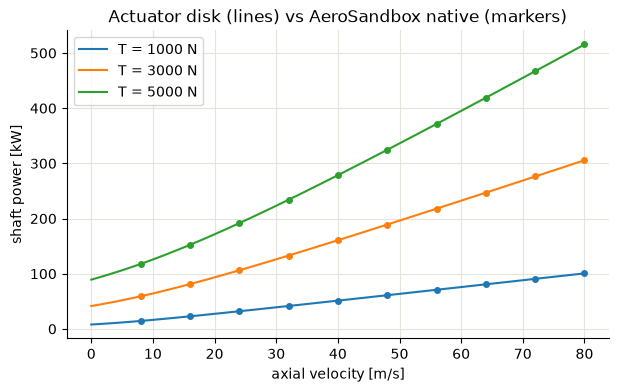

max relative error vs native: 0.00e+00
[PASS] propulsor: matches AeroSandbox native within 1e-9


In [12]:
# Agreement with AeroSandbox's native momentum-theory function across airspeed and thrust.
velocity_m_s = np.linspace(0, 80, 81)
fig, ax = plt.subplots()
max_rel_error = 0.0
for thrust in (1000, 3000, 5000):
    ours = rotor.evaluate(velocity_m_s, atmosphere, thrust_N=thrust).shaft_power_W
    native = propeller_shaft_power_from_thrust(thrust, rotor.area_disk_m2, velocity_m_s, rho_kg_m3, 0.8)
    max_rel_error = max(max_rel_error, float(np.max(np.abs(ours / native - 1))))
    line, = ax.plot(velocity_m_s, ours / 1e3, label=f"T = {thrust} N")
    ax.plot(velocity_m_s[::8], native[::8] / 1e3, "o", color=line.get_color(), ms=4)
ax.set(xlabel="axial velocity [m/s]", ylabel="shaft power [kW]",
       title="Actuator disk (lines) vs AeroSandbox native (markers)")
ax.legend()
plt.show()
print(f"max relative error vs native: {max_rel_error:.2e}")
check("propulsor: matches AeroSandbox native within 1e-9", max_rel_error < 1e-9)

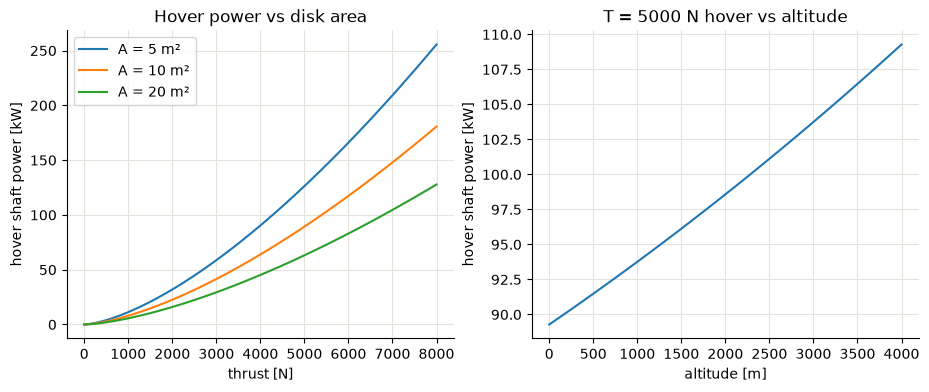

[PASS] propulsor: larger disk -> less hover power
[PASS] propulsor: higher altitude -> more hover power
[PASS] propulsor: better FoM -> less power


In [13]:
# Trends: disk loading and density altitude.
thrust_N = np.linspace(0, 8000, 200)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for area in (5, 10, 20):
    ax1.plot(thrust_N, ActuatorDiskPropulsor(area_disk_m2=area).evaluate(0, atmosphere, thrust_N=thrust_N).shaft_power_W / 1e3,
             label=f"A = {area} m²")
ax1.set(xlabel="thrust [N]", ylabel="hover shaft power [kW]", title="Hover power vs disk area")
ax1.legend()
altitude_m = np.linspace(0, 4000, 50)
hover_W = [rotor.evaluate(0, asb.Atmosphere(altitude=a), thrust_N=5000).shaft_power_W for a in altitude_m]
ax2.plot(altitude_m, np.array(hover_W) / 1e3)
ax2.set(xlabel="altitude [m]", ylabel="hover shaft power [kW]", title="T = 5000 N hover vs altitude")
plt.show()

check("propulsor: larger disk -> less hover power",
      ActuatorDiskPropulsor(area_disk_m2=20).evaluate(0, atmosphere, thrust_N=5000).shaft_power_W < h.shaft_power_W)
check("propulsor: higher altitude -> more hover power", np.all(np.diff(hover_W) > 0))
check("propulsor: better FoM -> less power", ideal_rotor.evaluate(0, atmosphere, thrust_N=5000).shaft_power_W < h.shaft_power_W)

In [14]:
# High axial speed: the rationalized root stays accurate where the naive form cancels.
velocity_m_s, thrust_N = 1e6, 1.0
vi_rationalized = rotor.evaluate(velocity_m_s, atmosphere, thrust_N=thrust_N).induced_velocity_m_s
vi_naive = 0.5 * (-velocity_m_s + np.sqrt(velocity_m_s**2 + 2 * thrust_N / (rho_kg_m3 * rotor.area_disk_m2)))
vi_asymptotic = thrust_N / (2 * rho_kg_m3 * rotor.area_disk_m2 * velocity_m_s)
print(f"rationalized {vi_rationalized:.6e}, naive {vi_naive:.6e}, asymptotic {vi_asymptotic:.6e}")
check("propulsor: rationalized root matches high-speed asymptote", close(vi_rationalized, vi_asymptotic, rel=1e-6))

rationalized 4.081635e-08, naive 4.080357e-08, asymptotic 4.081635e-08
[PASS] propulsor: rationalized root matches high-speed asymptote


### 7. AeroSandbox / CasADi symbolic compatibility

Every component must accept `opti.variable(...)` inputs and return CasADi `MX`
expressions with no Python branching on symbolic values. This includes the
propulsor's `np.where` zero-thrust guard and the battery's `np.maximum` sizing.

In [15]:
opti = asb.Opti()
speed_rad_s = opti.variable(init_guess=400, lower_bound=1)
torque_Nm = opti.variable(init_guess=200, lower_bound=0)
voltage_V = opti.variable(init_guess=800, lower_bound=1)
current_A = opti.variable(init_guess=100)
soc = opti.variable(init_guess=0.9)
thrust_N = opti.variable(init_guess=5000, lower_bound=1)
altitude_m = opti.variable(init_guess=0)
power_rated_W = opti.variable(init_guess=1e5, lower_bound=1)
opti.subject_to([speed_rad_s == 400, torque_Nm == 200, voltage_V == 800, current_A == 100,
                 soc == 0.9, thrust_N == 5000, altitude_m == 0, power_rated_W == 1e5])

symbolic = {
    "Motor.power_electric_W": (Motor().evaluate(speed_rad_s, torque_Nm, voltage_V).power_electric_W,
                               Motor().evaluate(400, 200, 800).power_electric_W),
    "Generator.power_electric_W": (Generator().evaluate(speed_rad_s, torque_Nm, voltage_V).power_electric_W,
                                   Generator().evaluate(400, 200, 800).power_electric_W),
    "Battery.soc_next": (Battery().evaluate(current_A, soc, 60).soc_next, Battery().evaluate(100, 0.9, 60).soc_next),
    "SimpleTurboshaft.fuel_flow_kg_s": (SimpleTurboshaft().evaluate(speed_rad_s * torque_Nm).fuel_flow_kg_s,
                                        SimpleTurboshaft().evaluate(80000).fuel_flow_kg_s),
    "Gearbox.power_output_W": (Gearbox().evaluate(speed_rad_s, torque_Nm).power_output_W,
                               Gearbox().evaluate(400, 200).power_output_W),
    "ActuatorDiskPropulsor.shaft_power_W": (
        ActuatorDiskPropulsor().evaluate(0, asb.Atmosphere(altitude=altitude_m), thrust_N=thrust_N).shaft_power_W,
        h.shaft_power_W),
    "Motor.get_mass (symbolic rating)": (Motor(power_rated_W=power_rated_W).get_mass(), Motor().get_mass()),
    "Battery.get_mass (symbolic rating)": (Battery(max_discharge_power_W=power_rated_W).get_mass(), Battery().get_mass()),
}
check("symbolic: every expression is casadi.MX", all(isinstance(s, cas.MX) for s, _ in symbolic.values()))
solution = opti.solve(verbose=False)
for name, (expression, numeric) in symbolic.items():
    value = float(solution.value(expression))
    check(f"symbolic: {name} = {value:.6g} matches numeric", close(value, numeric, rel=1e-7, abs_=1e-9))

[PASS] symbolic: every expression is casadi.MX
[PASS] symbolic: Motor.power_electric_W = 83333.3 matches numeric
[PASS] symbolic: Generator.power_electric_W = 76666.7 matches numeric
[PASS] symbolic: Battery.soc_next = 0.766667 matches numeric
[PASS] symbolic: SimpleTurboshaft.fuel_flow_kg_s = 0.00620155 matches numeric
[PASS] symbolic: Gearbox.power_output_W = 77600 matches numeric
[PASS] symbolic: ActuatorDiskPropulsor.shaft_power_W = 89285.7 matches numeric
[PASS] symbolic: Motor.get_mass (symbolic rating) = 20 matches numeric
[PASS] symbolic: Battery.get_mass (symbolic rating) = 40 matches numeric


## 3. Electric-machine loss model (McDonald)

*From `tier1_powertrain_components/motor_loss_model_verification.ipynb`.*

In [16]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import casadi as cas
import matplotlib.pyplot as plt

from aircraft_closure.powertrain.components.generator import Generator
from aircraft_closure.powertrain.components.motor import (McDonaldMotorLossModel, Motor, SimpleMotorLossModel,
                                                          rubber_machine)
from examples.series_hybrid_point import solve_topology_point

check_log = globals().get("check_log", [])


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


def close(a, b, rel=1e-9, abs_tol=1e-12):
    return abs(a - b) <= max(rel * abs(b), abs_tol)


def efficiency(model, speed_rad_s, torque_Nm):
    power_shaft_W = speed_rad_s * torque_Nm
    return power_shaft_W / (power_shaft_W + model.evaluate(speed_rad_s, torque_Nm, 800))


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

### 1. Coefficients and the peak-efficiency identities

At $(\hat\omega, \hat Q)$ the losses sum to $\hat\omega\hat Q(1-\hat\eta)/\hat\eta$,
so $\eta = \hat\eta$ exactly, and the efficiency gradient vanishes there (that is
how eqs. 2 were derived). $C_1$ simplifies to
$\hat Q(1-\hat\eta)(1-k_0)/(4\hat\eta) \ge 0$, so every coefficient is
non-negative on $k_0 \in [0, 1]$.

In [17]:
model = McDonaldMotorLossModel(speed_peak_efficiency_rad_s=500.0, torque_peak_efficiency_Nm=300.0,
                               efficiency_peak=0.95, parasite_loss_ratio=0.5)
c = model.coefficients()
print(c)
loss_ratio = 0.05 / 0.95
check("eq. 2: C0 = k0 w Q (1 - eta) / (6 eta)", close(c.constant_W, 0.5 * 500 * 300 * loss_ratio / 6))
check("eq. 2: C1 = Q (1 - eta)(1 - k0) / (4 eta)", close(c.linear_W_s_rad, 300 * loss_ratio * 0.5 / 4))
check("eq. 2: C2 = C0 / (2 w^3) + Q (1 - eta) / (4 eta w^2)",
      close(c.cubic_W_s3_rad3, c.constant_W / (2 * 500**3) + 300 * loss_ratio / (4 * 500**2)))
check("eq. 2: C3 = w (1 - eta) / (2 Q eta)", close(c.torque_W_Nm2, 500 * loss_ratio / (2 * 300)))
check("identity: efficiency at the peak point equals eta_hat", close(efficiency(model, 500.0, 300.0), 0.95))
h = 1e-3
gradient = ((efficiency(model, 500 + h, 300) - efficiency(model, 500 - h, 300)) / (2 * h),
            (efficiency(model, 500, 300 + h) - efficiency(model, 500, 300 - h)) / (2 * h))
print(f"efficiency gradient at the peak: {gradient}")
check("identity: efficiency gradient vanishes at the peak", max(abs(g) for g in gradient) < 1e-9)
check("identity: the peak is a maximum (all neighbours lower)",
      all(efficiency(model, 500 * (1 + ds), 300 * (1 + dq)) < 0.95
          for ds in (-0.05, 0, 0.05) for dq in (-0.05, 0, 0.05) if ds or dq))
valid = [McDonaldMotorLossModel(parasite_loss_ratio=k0).coefficients() for k0 in np.linspace(0, 1, 21)]
check("domain: all coefficients non-negative for k0 in [0, 1]",
      all(min(v.constant_W, v.linear_W_s_rad, v.cubic_W_s3_rad3, v.torque_W_Nm2) >= 0 for v in valid))
check("limit: k0 = 0 removes the constant loss", McDonaldMotorLossModel(parasite_loss_ratio=0).coefficients().constant_W == 0)
check("limit: eta_hat = 1 gives a lossless machine",
      McDonaldMotorLossModel(efficiency_peak=1.0).evaluate(700, 350, 800) == 0)

McDonaldLossCoefficients(constant_W=657.8947368421059, linear_W_s_rad=1.9736842105263177, cubic_W_s3_rad3=1.8421052631578968e-05, torque_W_Nm2=0.043859649122807064)
PASS  eq. 2: C0 = k0 w Q (1 - eta) / (6 eta)
PASS  eq. 2: C1 = Q (1 - eta)(1 - k0) / (4 eta)
PASS  eq. 2: C2 = C0 / (2 w^3) + Q (1 - eta) / (4 eta w^2)
PASS  eq. 2: C3 = w (1 - eta) / (2 Q eta)
PASS  identity: efficiency at the peak point equals eta_hat
efficiency gradient at the peak: (-5.551115123125783e-14, -5.551115123125783e-14)
PASS  identity: efficiency gradient vanishes at the peak
PASS  identity: the peak is a maximum (all neighbours lower)
PASS  domain: all coefficients non-negative for k0 in [0, 1]
PASS  limit: k0 = 0 removes the constant loss
PASS  limit: eta_hat = 1 gives a lossless machine


### 2. Reference case: the paper's Figure 1 rubber motor

Figure 1 of the paper shows the seven-parameter model with $\hat\eta$ = 95 %,
$k_0$ = 0.5 and $k_Q = k_P = k_\omega = 2$, on axes normalized by the peak point,
with contours at 25, 50, 75, 80, 85, 90, 93, 94 and 94.9 %. The same instance is
reproduced here through `rubber_machine`, inside the max-torque, max-power and
max-speed limits.

PASS  eq. 4: rated torque = kQ Q_hat
PASS  eq. 4: rated power = kP w_hat Q_hat
PASS  eq. 4: speed limit = kw w_hat


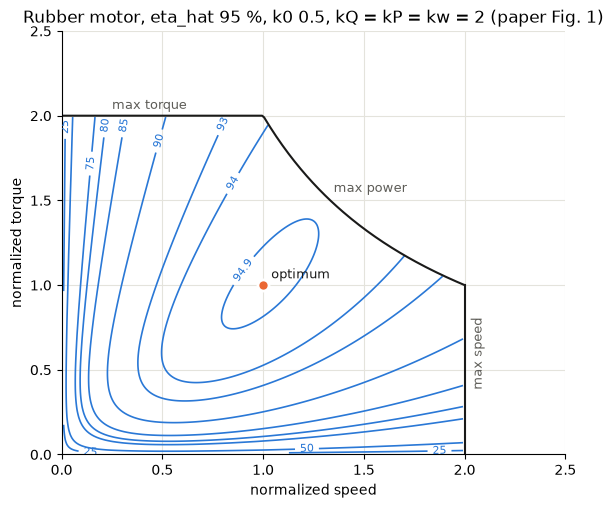

grid maximum 0.95000 at speed 1.001, torque 1.001
PASS  Fig. 1: grid maximum is the optimum (1, 1) within grid spacing
PASS  Fig. 1: maximum efficiency 95 %
PASS  Fig. 1: both envelope corners are below the peak and above 90 %
PASS  Fig. 1: torque-corner loss share follows C3 Q^2 dominance (rated corner above max-speed corner)
rated corner 0.9383, max-speed corner 0.9231


In [18]:
figure1 = rubber_machine(Motor, speed_peak_efficiency_rad_s=1.0, torque_peak_efficiency_Nm=1.0, efficiency_peak=0.95,
                         parasite_loss_ratio=0.5, torque_ratio=2, power_ratio=2, speed_ratio=2)
check("eq. 4: rated torque = kQ Q_hat", figure1.max_torque_Nm == 2.0)
check("eq. 4: rated power = kP w_hat Q_hat", figure1.power_rated_W == 2.0)
check("eq. 4: speed limit = kw w_hat", figure1.max_speed_rad_s == 2.0)

speed, torque = np.meshgrid(np.linspace(0.01, 2.5, 300), np.linspace(0.01, 2.5, 300))
eta = efficiency(figure1.loss_model, speed, torque)
inside = (torque <= 2) & (speed <= 2) & (speed * torque <= 2)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
levels = [0.25, 0.50, 0.75, 0.80, 0.85, 0.90, 0.93, 0.94, 0.949]
contours = ax.contour(speed, torque, np.where(inside, eta, np.nan), levels=levels, colors=blue, linewidths=1.2)
ax.clabel(contours, fmt=lambda v: f"{100 * v:g}", fontsize=8)
envelope_speed = np.linspace(0, 2, 200)
ax.plot(envelope_speed, np.minimum(2.0, 2.0 / np.maximum(envelope_speed, 1e-9)), color=ink, lw=1.5)
ax.plot([2, 2], [0, 1], color=ink, lw=1.5)
ax.plot([1], [1], "o", color=orange, ms=8, mec="white", mew=2)
ax.text(1.04, 1.04, "optimum", color=ink, fontsize=9)
ax.text(0.25, 2.04, "max torque", color=ink_muted, fontsize=9)
ax.text(1.35, 1.55, "max power", color=ink_muted, fontsize=9)
ax.text(2.03, 0.4, "max speed", color=ink_muted, fontsize=9, rotation=90)
ax.set(xlabel="normalized speed", ylabel="normalized torque", xlim=(0, 2.5), ylim=(0, 2.5),
       title="Rubber motor, eta_hat 95 %, k0 0.5, kQ = kP = kw = 2 (paper Fig. 1)")
plt.show()

eta_inside = np.where(inside, eta, 0)
peak_index = np.unravel_index(np.argmax(eta_inside), eta.shape)
print(f"grid maximum {eta_inside[peak_index]:.5f} at speed {speed[peak_index]:.3f}, torque {torque[peak_index]:.3f}")
check("Fig. 1: grid maximum is the optimum (1, 1) within grid spacing",
      abs(speed[peak_index] - 1) < 0.01 and abs(torque[peak_index] - 1) < 0.01)
check("Fig. 1: maximum efficiency 95 %", close(float(eta_inside.max()), 0.95, rel=1e-4))
# Corner values are model outputs recorded for reference; the paper's contour
# positions are not machine-readable from the PDF, so no figure match is claimed.
check("Fig. 1: both envelope corners are below the peak and above 90 %",
      all(0.90 < efficiency(figure1.loss_model, w, q) < 0.95 for w, q in ((1.0, 2.0), (2.0, 1.0))))
check("Fig. 1: torque-corner loss share follows C3 Q^2 dominance (rated corner above max-speed corner)",
      efficiency(figure1.loss_model, 1.0, 2.0) > efficiency(figure1.loss_model, 2.0, 1.0))
print(f"rated corner {efficiency(figure1.loss_model, 1.0, 2.0):.4f}, "
      f"max-speed corner {efficiency(figure1.loss_model, 2.0, 1.0):.4f}")

### 3. Rubber scaling and physical trends

Scaling $\hat Q$ by $s$ at fixed $\hat\omega$ and $\hat\eta$ scales every
coefficient so that losses at $(\omega, sQ)$ are exactly $s$ times those at
$(\omega, Q)$: a bigger machine of the same technology has the same efficiency
map in normalized coordinates. Efficiency falls at light torque (constant and
speed losses dominate) and at high speed ($C_2\omega^3$).

PASS  scaling: 4x peak torque gives exactly 4x losses at 4x torque
PASS  scaling: normalized efficiency map unchanged by rubber scaling
PASS  trend: efficiency drops at light torque
PASS  trend: efficiency drops at high speed
PASS  identity: k0 does not change losses at the peak speed
PASS  trend: larger k0 lowers low-speed efficiency


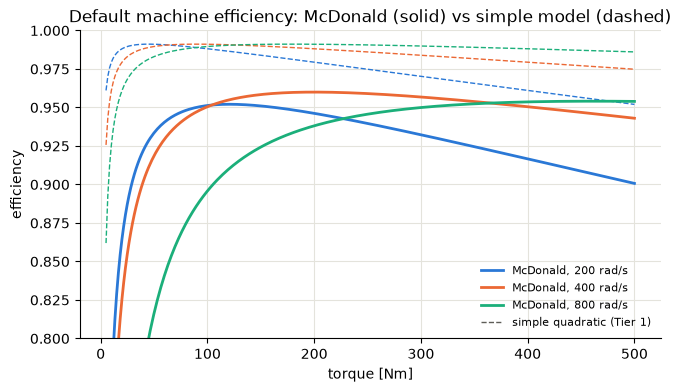

In [19]:
base = McDonaldMotorLossModel(400.0, 200.0)
scaled = McDonaldMotorLossModel(400.0, 800.0)
check("scaling: 4x peak torque gives exactly 4x losses at 4x torque",
      all(close(scaled.evaluate(w, 4 * q, 800), 4 * base.evaluate(w, q, 800)) for w, q in ((100, 50), (400, 200), (900, 450))))
check("scaling: normalized efficiency map unchanged by rubber scaling",
      close(efficiency(scaled, 300, 600), efficiency(base, 300, 150)))
check("trend: efficiency drops at light torque", efficiency(base, 400, 20) < efficiency(base, 400, 200))
check("trend: efficiency drops at high speed", efficiency(base, 1000, 200) < efficiency(base, 400, 200))
# At w = w_hat the speed-dependent terms total 2 Q_hat w_hat (1 - eta)/(4 eta)
# for any k0, so the parasite ratio only matters away from the peak speed.
check("identity: k0 does not change losses at the peak speed",
      close(McDonaldMotorLossModel(parasite_loss_ratio=0.9).evaluate(400, 40, 800),
            McDonaldMotorLossModel(parasite_loss_ratio=0.1).evaluate(400, 40, 800)))
check("trend: larger k0 lowers low-speed efficiency",
      efficiency(McDonaldMotorLossModel(parasite_loss_ratio=0.9), 100, 40)
      < efficiency(McDonaldMotorLossModel(parasite_loss_ratio=0.1), 100, 40))

torque_Nm = np.linspace(5, 500, 300)
fig, ax = plt.subplots(figsize=(7.5, 4))
for speed_rad_s, color in ((200, blue), (400, orange), (800, aqua)):
    ax.plot(torque_Nm, efficiency(base, speed_rad_s, torque_Nm), color=color, lw=2, label=f"McDonald, {speed_rad_s} rad/s")
    ax.plot(torque_Nm, efficiency(SimpleMotorLossModel(), speed_rad_s, torque_Nm), color=color, lw=1, ls="--")
ax.plot([], [], color=ink_muted, lw=1, ls="--", label="simple quadratic (Tier 1)")
ax.set(xlabel="torque [Nm]", ylabel="efficiency", ylim=(0.80, 1.0),
       title="Default machine efficiency: McDonald (solid) vs simple model (dashed)")
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.show()

### 4. Default machines and the reference hover point

Defaults put the peak at the reference hover operating point (400 rad/s, 200 Nm)
with $\hat\eta$ = 0.96. Motor and generator share the loss function; generator
efficiency is $P_e/P_s = 1 - P_L/(\omega Q)$. $C_0$ is a constant loss present even
at standstill (domain $\omega, Q \ge 0$). The coupled reference point keeps its
rotor shaft power (losses act on the electrical side only) while battery power
and fuel flow rise to cover the more realistic machine losses.

In [20]:
motor, generator = Motor(), Generator()
m = motor.evaluate(400, 200, 800)
g = generator.evaluate(400, 200, 800)
print(f"motor efficiency {m.power_shaft_W / m.power_electric_W:.4f}, generator efficiency "
      f"{g.power_electric_W / g.power_shaft_W:.4f}")
check("default: motor efficiency at the reference point is 0.96", close(m.power_shaft_W / m.power_electric_W, 0.96))
check("default: generator shares the losses", close(g.power_loss_W, m.power_loss_W))
check("default: standstill loss equals C0", close(motor.evaluate(0, 0, 800).power_loss_W,
                                                  motor.loss_model.coefficients().constant_W))
point = solve_topology_point()
print(point)
check("reference point: rotor shaft power unchanged (89.286 kW)", close(point.shaft_power_W, 89285.745, rel=1e-5))
check("reference point: battery power 19.184 kW with McDonald losses", close(point.battery_power_W, 19184.051, rel=1e-5))
check("reference point: fuel flow 0.006207 kg/s with McDonald losses", close(point.fuel_flow_kg_s, 0.0062072, rel=1e-4))
quad = solve_topology_point(count_rotors=4)
check("reference point: rubber-scaled generator makes 4-rotor fuel flow exactly 4x",
      close(quad.fuel_flow_kg_s, 4 * point.fuel_flow_kg_s, rel=1e-6))

motor efficiency 0.9600, generator efficiency 0.9583
PASS  default: motor efficiency at the reference point is 0.96
PASS  default: generator shares the losses
PASS  default: standstill loss equals C0
TopologyPointResult(thrust_N=5000.000000017698, shaft_power_W=89285.7450473679, battery_power_W=19184.05069950873, fuel_flow_kg_s=0.006207175261400091, bus_power_residual_W=-1.678272383287549e-07, rotor_power_residual_W=-9.478681022301316e-07, current_motor_A=120.08055862903403, current_motors_total_A=120.08055862903403, voltage_bus_V=798.7991944137106, max_abs_connection_residual=2.1010748696426162e-10, min_operating_margin=0.0795284015735268, binding_margin_label='motor power_shaft_W')
PASS  reference point: rotor shaft power unchanged (89.286 kW)
PASS  reference point: battery power 19.184 kW with McDonald losses
PASS  reference point: fuel flow 0.006207 kg/s with McDonald losses


PASS  reference point: rubber-scaled generator makes 4-rotor fuel flow exactly 4x


### 5. Symbolic parameters

All four parameters may be Opti variables, so a later sizing problem can scale
the rubber machine. Minimizing the loss at a fixed operating point over $\hat Q$
recovers $\hat Q$ = the operating torque: a machine is most efficient where its
peak sits.

In [21]:
opti = asb.Opti()
torque_peak_Nm = opti.variable(init_guess=120, lower_bound=1)
loss_W = McDonaldMotorLossModel(torque_peak_efficiency_Nm=torque_peak_Nm).evaluate(400, 200, 800)
check("symbolic: loss with a symbolic peak torque is CasADi MX", isinstance(loss_W, cas.MX))
opti.minimize(loss_W / 1e3)
solution = opti.solve(verbose=False)
print(f"optimal peak torque {solution.value(torque_peak_Nm):.4f} Nm")
check("symbolic: loss-minimizing peak torque equals the operating torque",
      close(float(solution.value(torque_peak_Nm)), 200.0, rel=1e-5))

PASS  symbolic: loss with a symbolic peak torque is CasADi MX
optimal peak torque 200.0000 Nm
PASS  symbolic: loss-minimizing peak torque equals the operating torque


## 4. Machine mass against speed

*From `tier13_machines/machine_sizing_verification.ipynb`.*

In [22]:
import sys
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from aircraft_closure.powertrain.components.motor import Motor, TorqueDensityMassModel, rubber_machine
from examples.halo_sizing import (HaloAssumptions, HaloRequirements, assumptions_tier12b, requirements_tier12b,
                                  solve_halo_sizing)

# Tier 13 record: without the Tier 16 hot-day hover.
R13 = requirements_tier12b

check_log = globals().get("check_log", [])


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

# Plan 022 made the 780 kg equivalent-circuit pack the reference; this notebook keeps reproducing its own tier
# (900 kg, constant-OCV battery).
from functools import partial
from examples.halo_sizing import HaloAssumptions as _HaloAssumptions, HaloRequirements as _HaloRequirements
from examples.halo_sizing import solve_halo_sizing as _solve_halo_sizing
HaloAssumptions = partial(_HaloAssumptions, drag_corrections=False, redundancy=False, machine_mass_model="torque_density", gearbox_stages=False,
                          battery_model="constant", wing_weight_model="raymer",
                          aerodynamics_model="simple", thermal_model=False)
HaloRequirements = partial(_HaloRequirements, mass_payload_kg=900.0)
solve_halo_sizing = partial(_solve_halo_sizing, requirements=HaloRequirements(), assumptions=HaloAssumptions())

### 1. Machine mass against speed at fixed power

At fixed power, torque falls as 1/speed, so a torque-sized machine gets
lighter as it spins faster, until the specific-power cap takes over. The
specific-power model (Tiers 1–12b) is flat.

PASS  torque-sized mass falls with speed, then flattens at the specific-power cap


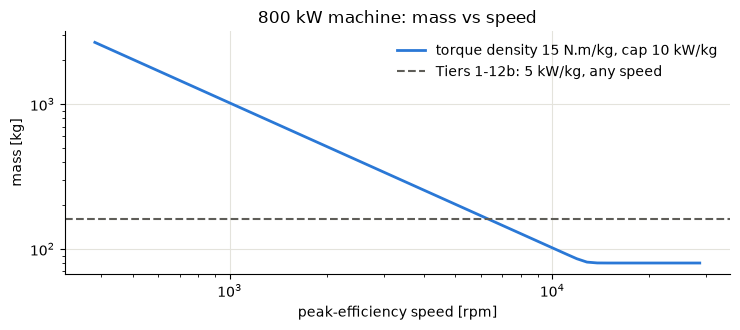

In [23]:
power_W = 800e3
speeds = np.geomspace(40, 3000, 60)
model = TorqueDensityMassModel()
torque_mass = [float(rubber_machine(Motor, w, power_W / (1.25 * w), torque_ratio=2.5, power_ratio=1.25, speed_ratio=2.5,
                                    mass_model=model).get_mass()) for w in speeds]
flat = power_W / 5000.0
check("torque-sized mass falls with speed, then flattens at the specific-power cap",
      torque_mass[0] > 10 * torque_mass[-1] and abs(torque_mass[-1] - power_W / 10000.0) < 3)
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.loglog(speeds * 60 / (2 * np.pi), torque_mass, color=blue, lw=2, label="torque density 15 N.m/kg, cap 10 kW/kg")
ax.axhline(flat, color=ink_muted, lw=1.5, ls="--", label="Tiers 1-12b: 5 kW/kg, any speed")
ax.set(xlabel="peak-efficiency speed [rpm]", ylabel="mass [kg]", title="800 kW machine: mass vs speed")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 5. Machines from a supplier database, and gearbox stages

*From `tier13b_machine_database/machine_database_verification.ipynb`.*

In [24]:
import sys
import time
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
for path in (repo_root / "src", repo_root):     # this checkout's package even if another one is installed
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import aerosandbox as asb
import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from aircraft_closure.powertrain.components.gearbox import GearStageModel
from aircraft_closure.powertrain.components.motor import DatabaseMassModel, Motor, TorqueDensityMassModel, rubber_machine
from aircraft_closure.powertrain.machine_database import fit_torque_density, load_machine_database
from aircraft_closure.weights import afdd
from examples.halo_sizing import (HaloAssumptions, assumptions_plan027, ratio_reference_gear_stages, solve_halo_sizing,
                                  stage_mass_ratio)

# Plan 035 changed the defaults (drag corrections, redundancy, unit-built machines, gearbox stages); this notebook
# keeps reproducing its own tier on the plan 030 settings.
from functools import partial
from examples.halo_sizing import HaloAssumptions as _HaloAssumptions, solve_halo_sizing as _solve_halo_sizing
from examples.halo_sizing import pre_layout, pre_plan035 as _pre_plan035
HaloAssumptions = partial(_HaloAssumptions, **_pre_plan035, **pre_layout)
solve_halo_sizing = partial(_solve_halo_sizing, assumptions=HaloAssumptions())
from examples.xv15_reference import calibration_factors

check_log = globals().get("check_log", [])


def check(name, passed):
    # Record and print one named verification.
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua, yellow, violet = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#8a5cd6"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8,
                     "axes.labelcolor": ink, "xtick.color": ink_muted, "ytick.color": ink_muted,
                     "axes.titlesize": 11, "axes.titleweight": "bold", "font.size": 9.5})
rpm = u.rpm
ratios = dict(torque_ratio=2.5, power_ratio=1.25, speed_ratio=2.5)    # the Halo rubber machine
fast = replace(assumptions_plan027, aerodynamics_model="scholz")

### 1. The database and the torque-density fit

The speed class of a machine is its base speed, w = P_cont / T_cont. For the Halo `rubber_machine` this is the
peak-efficiency speed: continuous torque = 0.5 x peak torque.

The fit uses bare machines, or machines whose inverter status is unknown, that publish continuous torque and
power. Two kinds of rows are plotted and compared but not fitted:

- integrated rows (inverter included): the comparison adds an inverter at 20 kW/kg;
- peak-only rows: the comparison takes continuous = 0.5 x peak.

In [25]:
records = load_machine_database()
fit = fit_torque_density(records)
residual = dict(fit.residuals)
print(f"{'machine':22s} {'type':7s} {'inv':7s} {'mass kg':>8s} {'T_cont':>7s} {'T_peak':>7s} {'P_cont kW':>9s} "
      f"{'base rpm':>8s} {'N m/kg':>7s} {'kW/kg':>6s} {'fit':>4s} {'model/db':>8s}")
for r in records:
    w = r.speed_base_rad_s()
    tau = r.torque_density_continuous_Nm_kg()
    fmt = lambda v, f: (f % v) if v is not None else "-"
    print(f"{r.name:22s} {r.topology:7s} {r.inverter_included:7s} {r.mass_kg:8.1f} {fmt(r.torque_continuous_Nm, '%7.0f'):>7s} "
          f"{fmt(r.torque_peak_Nm, '%7.0f'):>7s} {fmt(r.power_continuous_W and r.power_continuous_W / 1e3, '%9.0f'):>9s} "
          f"{fmt(w and w / rpm, '%8.0f'):>8s} {fmt(tau, '%7.1f'):>7s} "
          f"{fmt(r.power_continuous_W and r.power_continuous_W / r.mass_kg / 1e3, '%6.1f'):>6s} {'y' if r.fit else 'n':>4s} "
          f"{fmt(residual.get(r.name), '%8.2f'):>8s}")
print(f"\nfit: tau = {fit.torque_density_ref_Nm_kg:.2f} N m/kg x (w / {fit.speed_ref_rad_s:.0f} rad/s)^-{fit.exponent_speed:.3f}; "
      f"RMS log residual {fit.rms_log_residual:.3f} (x/ {np.exp(fit.rms_log_residual):.2f})")

machine                type    inv      mass kg  T_cont  T_peak P_cont kW base rpm  N m/kg  kW/kg  fit model/db
D1500 2x3              axial   n           40.0       -    1500         -     1800       -      -    n        -
D1500 1x3              axial   n           35.0       -    1450         -        -       -      -    n        -
D250                   axial   unknown      8.3     208     230       207     9503    25.1   24.9    y     2.56
E800                   axial   y           28.3     800       -       110     1313    28.3    3.9    n        -
SPX242 demonstrator    radial  n           31.2     324     470       315     9284    10.4   10.1    y     1.05
SPX242-50              radial  n           24.0     163     250       191    11190     6.8    8.0    y     0.73
SPX242-94              radial  n           34.0     331     470       278     8020     9.7    8.2    y     0.95
SPX242-175             radial  n           51.0     556     925       307     5273    10.9    6.0    y  

PASS  defaults equal the re-fit (tau_ref, exponent)
PASS  torque density falls with speed (0 < a < 1, so specific power still rises)
PASS  every fitted machine within a factor of 2.6
PASS  RMS log residual below 0.4
PASS  Helix SPX242 family and EMRAX within 30 %
PASS  every row cites an https source


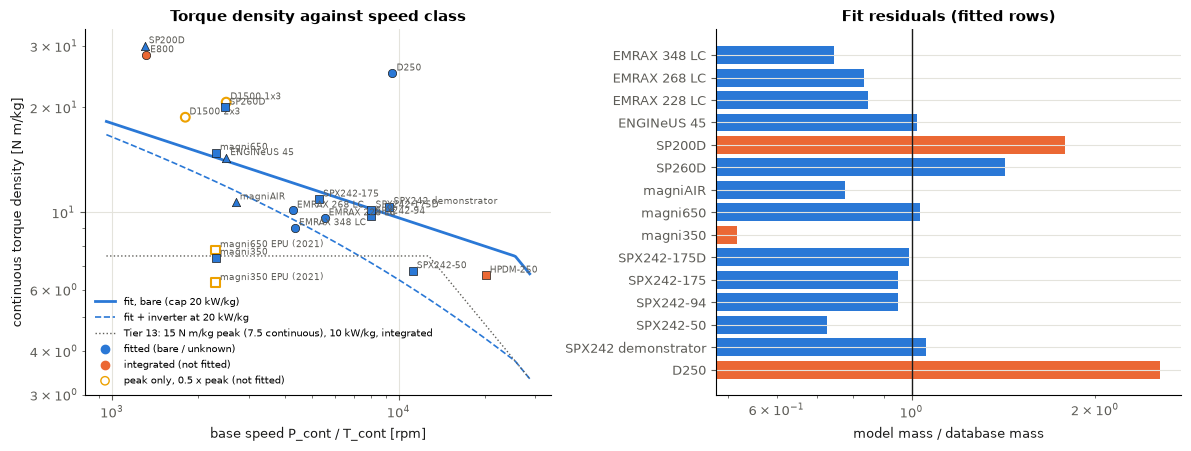

In [26]:
model_bare = DatabaseMassModel(specific_power_max_W_kg=20000.0, smoothing_kg=1e-6)
speed_rad_s = np.geomspace(100, 3000, 300)


def torque_density_model(w, inverter_W_kg=None):
    # Continuous torque density of a whole machine at base speed w (rating 1 N m continuous).
    machine = Motor(power_rated_W=w * 1.0, max_torque_Nm=2.0)
    model = replace(model_bare, specific_power_inverter_W_kg=inverter_W_kg)
    return 1.0 / model.mass_kg(machine)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))
ax1.plot(speed_rad_s / rpm, [torque_density_model(w) for w in speed_rad_s], color=blue, lw=2,
         label="fit, bare (cap 20 kW/kg)")
ax1.plot(speed_rad_s / rpm, [torque_density_model(w, 20000.0) for w in speed_rad_s], color=blue, lw=1.2, ls="--",
         label="fit + inverter at 20 kW/kg")
ax1.plot(speed_rad_s / rpm, [1.0 / TorqueDensityMassModel(15.0, 10000.0, 1e-6).mass_kg(
    Motor(power_rated_W=w * 1.0, max_torque_Nm=2.0)) for w in speed_rad_s], color=ink_muted, lw=1, ls=":",
         label="Tier 13: 15 N m/kg peak (7.5 continuous), 10 kW/kg, integrated")
markers = dict(axial="o", radial="s", unknown="^")
for r in records:
    if r.torque_continuous_Nm is not None:
        w, tau = r.speed_base_rad_s(), r.torque_density_continuous_Nm_kg()
        color = blue if r.fit else orange
        ax1.scatter(w / rpm, tau, marker=markers[r.topology], color=color, edgecolor=ink, lw=0.5, zorder=3, s=36)
    else:
        w = r.speed_rated_rad_s or r.speed_max_rad_s
        ax1.scatter(w / rpm, 0.5 * r.torque_peak_Nm / r.mass_kg, marker=markers[r.topology], facecolor="none",
                    edgecolor=yellow, lw=1.5, zorder=3, s=40)
    ax1.annotate(r.name, (w / rpm, (r.torque_density_continuous_Nm_kg() or 0.5 * r.torque_peak_Nm / r.mass_kg)),
                 fontsize=6.5, color=ink_muted, xytext=(3, 2), textcoords="offset points")
ax1.scatter([], [], color=blue, label="fitted (bare / unknown)")
ax1.scatter([], [], color=orange, label="integrated (not fitted)")
ax1.scatter([], [], facecolor="none", edgecolor=yellow, label="peak only, 0.5 x peak (not fitted)")
ax1.set(xscale="log", yscale="log", xlabel="base speed P_cont / T_cont [rpm]",
        ylabel="continuous torque density [N m/kg]", title="Torque density against speed class")
ax1.legend(frameon=False, fontsize=7.5, loc="lower left")
names = [n for n, _ in fit.residuals]
ax2.barh(names, [x for _, x in fit.residuals], color=[orange if abs(np.log(x)) > np.log(1.5) else blue
                                                      for _, x in fit.residuals])
ax2.axvline(1.0, color=ink, lw=1)
ax2.set(xscale="log", xlabel="model mass / database mass", title="Fit residuals (fitted rows)")
plt.tight_layout()

check("defaults equal the re-fit (tau_ref, exponent)",
      abs(DatabaseMassModel().torque_density_ref_Nm_kg - fit.torque_density_ref_Nm_kg) < 0.01
      and abs(DatabaseMassModel().exponent_speed - fit.exponent_speed) < 0.001)
check("torque density falls with speed (0 < a < 1, so specific power still rises)", 0 < fit.exponent_speed < 1)
check("every fitted machine within a factor of 2.6", all(abs(np.log(x)) < np.log(2.6) for _, x in fit.residuals))
check("RMS log residual below 0.4", fit.rms_log_residual < 0.4)
check("Helix SPX242 family and EMRAX within 30 %",
      all(abs(x - 1) < 0.3 for n, x in fit.residuals if n.startswith(("SPX242", "EMRAX"))))
check("every row cites an https source", all(r.source_url.startswith("https://") for r in records))

**Reading the fit:**

- The scatter is large. At about 2,300-2,500 rpm, continuous torque density runs from 7.4 N m/kg (magni350,
  165 kW continuous of 350 kW peak) to 30 N m/kg (Siemens SP200D).
- The best low-speed machines are about 1.8 times the fleet fit: the SP200D at 30 N m/kg and the SP260D at
  20 N m/kg. So is the Evolito D250, at 25 N m/kg near 9,500 rpm.
- The exponent a = 0.27 is weak. At fixed power the mass falls as w^-0.73, so the data alone still favour fast
  machines until the specific-power cap binds.
- The cap is the Tier 15 bare-machine assumption (20 kW/kg). No fitted machine except the D250 reaches it, so the
  data do not constrain it. Section 6 shows its sensitivity.

### 2. Stacking

Evolito stacks D250 and D500 units into one propulsion unit (newatlas.com, evtol.news). Its "1x3 / 2x3" D1500
suffix is the winding-set arrangement, not a stack count (magneticsmag.com).

A stacked machine carries n times the torque of one stack at the same speed. With the fitted mass linear in torque
at fixed speed, n stacks weigh n times one stack, plus `mass_overhead_stack_kg` per stack (default 0, because the
fit is to whole machines). The stack count is relaxed (continuous): T_cont / T_stack_max. At the fitted level it
does not change the mass; it is reported.

The Helix SPX242 family is one lamination built at stack lengths of 50, 94 and 175 mm. A straight line through it
gives the cost of length scaling: a fixed mass (end windings, housing, bearings) plus an incremental torque
density.

Helix SPX242 family: mass = 12.2 kg + T_cont / 14.5 N m/kg
PASS  relaxed stack count = T_cont / T_stack_max
PASS  three stacks weigh three times one (no overhead)
PASS  overhead adds per stack
PASS  length scaling has a positive fixed mass (Helix)


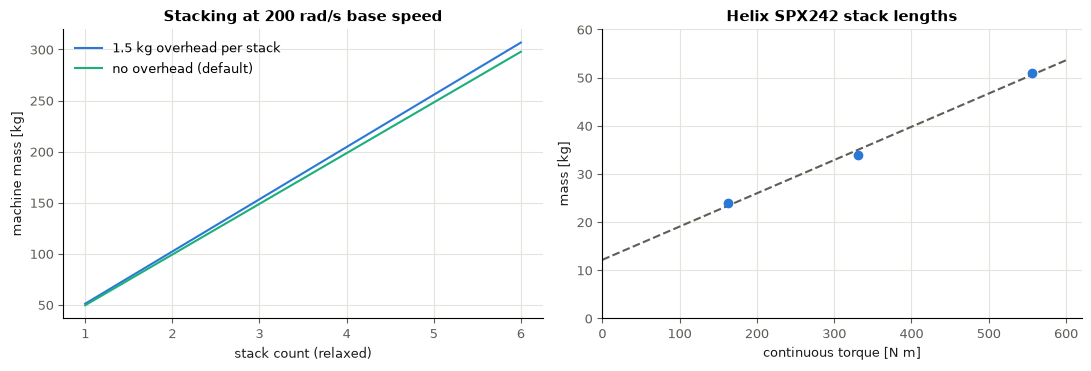

In [27]:
helix = [r for r in records if r.name in ("SPX242-50", "SPX242-94", "SPX242-175")]
torque = np.array([r.torque_continuous_Nm for r in helix]); mass = np.array([r.mass_kg for r in helix])
slope_kg_Nm, mass_fixed_kg = np.polyfit(torque, mass, 1)
print(f"Helix SPX242 family: mass = {mass_fixed_kg:.1f} kg + T_cont / {1 / slope_kg_Nm:.1f} N m/kg")

unit = rubber_machine(Motor, 200.0, 600.0, **ratios)
model = DatabaseMassModel(torque_continuous_max_stack_Nm=0.5 * 2.5 * 600.0, mass_overhead_stack_kg=1.5, smoothing_kg=1e-6)
plain = DatabaseMassModel(smoothing_kg=1e-6)
counts = np.linspace(1, 6, 26)
stacked_mass = [float(model.mass_kg(rubber_machine(Motor, 200.0, n * 600.0, **ratios))) for n in counts]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.plot(counts, stacked_mass, color=blue, label="1.5 kg overhead per stack")
ax1.plot(counts, [float(plain.mass_kg(rubber_machine(Motor, 200.0, n * 600.0, **ratios))) for n in counts], color=aqua,
         label="no overhead (default)")
ax1.set(xlabel="stack count (relaxed)", ylabel="machine mass [kg]", title="Stacking at 200 rad/s base speed")
ax1.legend(frameon=False)
ax2.scatter(torque, mass, color=blue, zorder=3)
t_line = np.linspace(0, 600, 10)
ax2.plot(t_line, mass_fixed_kg + slope_kg_Nm * t_line, color=ink_muted, ls="--")
ax2.set(xlabel="continuous torque [N m]", ylabel="mass [kg]", title="Helix SPX242 stack lengths", xlim=(0, 620), ylim=(0, 60))
plt.tight_layout()

three = rubber_machine(Motor, 200.0, 1800.0, **ratios)
check("relaxed stack count = T_cont / T_stack_max", abs(float(model.count_stacks(three)) - 3.0) < 1e-12)
check("three stacks weigh three times one (no overhead)",
      abs(float(plain.mass_kg(three)) - 3 * float(plain.mass_kg(unit))) < 1e-4)
check("overhead adds per stack", abs(float(model.mass_kg(three) - plain.mass_kg(three)) - 4.5) < 1e-6)
check("length scaling has a positive fixed mass (Helix)", mass_fixed_kg > 0)

### 3. Gearbox stage count

Let x = ln(ratio) / ln(5).

- The staircase is n = 1 + sum_k sigmoid((x - k) / 0.02 - 3). Each step sits 3 widths past the integer, so one
  stage covers ratios up to 5 (n = 1.047 at 5:1).
- The relaxed form is a softplus max(1, x).
- Efficiency is 0.99 x 0.99^n: 0.980, 0.970 and 0.961.
- The mass factor is 1 + 0.3 (n - 1).

In Halo, the AFDD00 drive mass is taken at the XV-15 ratio (35.4:1, three stages here, where the transmission
factor is calibrated) and scaled by mass_factor(ratio) / mass_factor(35.4).

PASS  one stage for ratio <= 5 (within 0.05)
PASS  staircase monotonic
PASS  relaxed monotonic
PASS  ceil away from the steps (6.5 -> 2, 24 -> 2, 36 -> 3, 100 -> 3)
PASS  efficiency 0.970 at two stages (the Tier 13 constant)
PASS  stage model neutral at the XV-15 calibration ratio
PASS  both models solve together inside asb.Opti


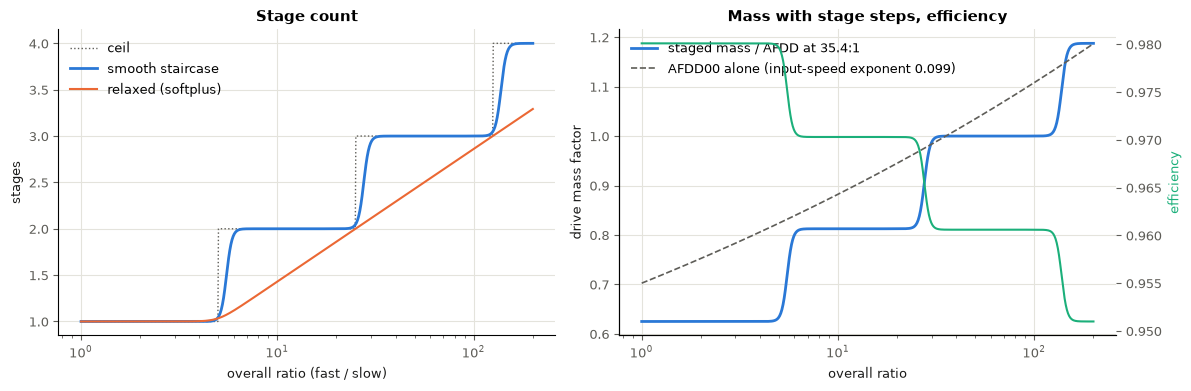

In [28]:
stage = GearStageModel()
relaxed = GearStageModel(staircase=False)
ratio = np.geomspace(1.0, 200.0, 800)
n_stair = np.array([float(stage.count_stages(r)) for r in ratio])
n_relaxed = np.array([float(relaxed.count_stages(r)) for r in ratio])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ratio, np.maximum(1, np.ceil(np.log(ratio) / np.log(5) - 1e-12)), color=ink_muted, lw=1, ls=":", label="ceil")
ax1.plot(ratio, n_stair, color=blue, lw=2, label="smooth staircase")
ax1.plot(ratio, n_relaxed, color=orange, lw=1.5, label="relaxed (softplus)")
ax1.set(xscale="log", xlabel="overall ratio (fast / slow)", ylabel="stages", title="Stage count")
ax1.legend(frameon=False)
afdd_ratio_factor = (ratio / ratio_reference_gear_stages()) ** 0.09899
ax2.plot(ratio, [float(stage_mass_ratio(stage, r)) for r in ratio], color=blue, lw=2,
         label="staged mass / AFDD at 35.4:1")
ax2.plot(ratio, afdd_ratio_factor, color=ink_muted, lw=1.2, ls="--", label="AFDD00 alone (input-speed exponent 0.099)")
ax2b = ax2.twinx()
ax2b.plot(ratio, [float(stage.efficiency(r)) for r in ratio], color=aqua, lw=1.5, label="efficiency")
ax2b.set_ylabel("efficiency", color=aqua); ax2b.grid(False)
ax2.set(xscale="log", xlabel="overall ratio", ylabel="drive mass factor", title="Mass with stage steps, efficiency")
ax2.legend(frameon=False, loc="upper left")
plt.tight_layout()

check("one stage for ratio <= 5 (within 0.05)", all(abs(float(stage.count_stages(r)) - 1) < 0.05 for r in (1.0, 3.0, 5.0)))
check("staircase monotonic", np.all(np.diff(n_stair) >= -1e-12))
check("relaxed monotonic", np.all(np.diff(n_relaxed) >= -1e-12))
check("ceil away from the steps (6.5 -> 2, 24 -> 2, 36 -> 3, 100 -> 3)",
      all(abs(float(stage.count_stages(r)) - n) < 0.02 for r, n in ((6.5, 2), (24, 2), (36, 3), (100, 3))))
check("efficiency 0.970 at two stages (the Tier 13 constant)", abs(float(stage.efficiency(20.0)) - 0.970) < 1e-3)
check("stage model neutral at the XV-15 calibration ratio",
      abs(float(stage_mass_ratio(stage, ratio_reference_gear_stages())) - 1) < 1e-12)

opti = asb.Opti()
r_var = opti.variable(init_guess=8.0, lower_bound=1.5, upper_bound=40.0)
m_var = opti.variable(init_guess=1000.0, lower_bound=50.0, upper_bound=3000.0)
motor = rubber_machine(Motor, m_var, 4e5 / m_var, mass_model=DatabaseMassModel(specific_power_inverter_W_kg=2e4), **ratios)
opti.subject_to(m_var == 40.0 * r_var)
opti.minimize(motor.get_mass() + 100 * stage.mass_factor(r_var))
sol = opti.solve(verbose=False)
check("both models solve together inside asb.Opti", sol.value(motor.get_mass()) > 0)

## 6. Topology

*From `tier2_powertrain_topology/topology_verification.ipynb`.*

In [29]:
import ast
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import casadi as cas
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

from aircraft_closure.core.ports import (Direction, Domain, ElectricalPortValue, FuelPortValue,
                                         MechanicalPortValue, PortSpec)
from aircraft_closure.core.topology import Topology, connection_residuals
from aircraft_closure.powertrain.components.battery import Battery
from aircraft_closure.powertrain.components.gearbox import Gearbox
from aircraft_closure.powertrain.components.generator import Generator
from aircraft_closure.powertrain.components.motor import Motor
from aircraft_closure.powertrain.components.propulsor import ActuatorDiskPropulsor
from aircraft_closure.powertrain.components.turboshaft import SimpleTurboshaft
from aircraft_closure.powertrain.ports import port_specs_for
from aircraft_closure.powertrain.topologies import build_series_hybrid
from examples.series_hybrid_point import build_reference_topology, solve_topology_point
from examples.series_hybrid_point_explicit import solve_reference_point

check_log = globals().get("check_log", [])


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


def close(a, b, rel=1e-9, abs_tol=1e-12):
    return abs(a - b) <= max(rel * abs(b), abs_tol)


def raises(error_type, action):
    """True when `action()` raises `error_type`; prints the message for the reader."""
    try:
        action()
    except error_type as error:
        print(f"    {error_type.__name__}: {error}")
        return True
    return False


# Categorical slots 1-3 (blue, orange, aqua) of the validated reference palette.
domain_colors = {Domain.MECHANICAL: "#2a78d6", Domain.ELECTRICAL: "#eb6834", Domain.FUEL: "#1baf7a"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e4e3dc", "grid.linewidth": 0.8})

### 1. Port declarations and sign conventions

Every port has one domain and one nominal power/fuel direction. The flow variable
(torque, current, fuel flow) is positive when power flows in that direction, which
keeps the Tier 1 signs: motor current is drawn **in**, generator current is
delivered **out**, battery current is **out** on discharge (negative when
charging). Declarations live in `powertrain/ports.py`, so the component classes and
their `get_mass`/`get_limits`/`evaluate` interface are unchanged.

In [30]:
tier1_components = [Motor(), Generator(), Battery(), SimpleTurboshaft(), Gearbox(), ActuatorDiskPropulsor()]
print(f"{'component':<24}{'port':<12}{'domain':<12}direction")
for component in tier1_components:
    for port in port_specs_for(component):
        print(f"{type(component).__name__:<24}{port.name:<12}{port.domain.value:<12}{port.direction.value}")

expected_ports = {
    "Motor": {("electrical", Domain.ELECTRICAL, Direction.IN), ("shaft", Domain.MECHANICAL, Direction.OUT)},
    "Generator": {("shaft", Domain.MECHANICAL, Direction.IN), ("electrical", Domain.ELECTRICAL, Direction.OUT)},
    "Battery": {("electrical", Domain.ELECTRICAL, Direction.OUT)},
    "SimpleTurboshaft": {("fuel", Domain.FUEL, Direction.IN), ("shaft", Domain.MECHANICAL, Direction.OUT)},
    "Gearbox": {("shaft_in", Domain.MECHANICAL, Direction.IN), ("shaft_out", Domain.MECHANICAL, Direction.OUT)},
    "ActuatorDiskPropulsor": {("shaft", Domain.MECHANICAL, Direction.IN)},
}
print()
for component in tier1_components:
    name = type(component).__name__
    declared = {(p.name, p.domain, p.direction) for p in port_specs_for(component)}
    check(f"ports: {name} declares the expected ports and directions", declared == expected_ports[name])


class TunedMotor(Motor):
    pass


check("ports: subclasses inherit their parent's declaration", port_specs_for(TunedMotor()) == port_specs_for(Motor()))
check("ports: undeclared component rejected", raises(TypeError, lambda: port_specs_for(object())))
check("ports: components expose no port methods (Tier 1 interface unchanged)",
      not any(hasattr(c, attr) for c in tier1_components for attr in ("ports", "get_ports")))

component               port        domain      direction
Motor                   electrical  electrical  in
Motor                   shaft       mechanical  out
Generator               shaft       mechanical  in
Generator               electrical  electrical  out
Battery                 electrical  electrical  out
SimpleTurboshaft        fuel        fuel        in
SimpleTurboshaft        shaft       mechanical  out
Gearbox                 shaft_in    mechanical  in
Gearbox                 shaft_out   mechanical  out
ActuatorDiskPropulsor   shaft       mechanical  in

PASS  ports: Motor declares the expected ports and directions
PASS  ports: Generator declares the expected ports and directions
PASS  ports: Battery declares the expected ports and directions
PASS  ports: SimpleTurboshaft declares the expected ports and directions
PASS  ports: Gearbox declares the expected ports and directions
PASS  ports: ActuatorDiskPropulsor declares the expected ports and directions
PASS  ports: subcla

### 2. Build-time validation

Topology structure is plain Python (never symbolic), so wiring errors are rejected
when `connect` is called, before any `asb.Opti` exists. A direct connection joins
exactly one OUT port to one IN port of the same domain and instance count; a port
connects once; junctions require a bus, and only electrical buses exist at this
tier.

In [31]:
shaft_out = PortSpec("shaft", Domain.MECHANICAL, Direction.OUT)
shaft_in = PortSpec("shaft", Domain.MECHANICAL, Direction.IN)
electrical_in = PortSpec("electrical", Domain.ELECTRICAL, Direction.IN)


def network(**instances):
    topology = Topology()
    for name, (ports, count) in instances.items():
        topology.add(name, object(), ports, count=count)
    return topology


t = network(a=((shaft_out,), 1), b=((electrical_in,), 1))
check("validation: domain mismatch rejected", raises(ValueError, lambda: t.connect("a.shaft", "b.electrical")))
t = network(a=((shaft_out,), 1), b=((shaft_out,), 1))
check("validation: OUT-to-OUT rejected", raises(ValueError, lambda: t.connect("a.shaft", "b.shaft")))
t = network(a=((shaft_out,), 1), b=((shaft_in,), 2))
check("validation: count mismatch needs a splitter (deferred)", raises(ValueError, lambda: t.connect("a.shaft", "b.shaft")))
t = network(a=((shaft_out,), 1), b=((shaft_in,), 1), c=((shaft_in,), 1))
t.connect("a.shaft", "b.shaft")
check("validation: a shaft port connects only once", raises(ValueError, lambda: t.connect("a.shaft", "c.shaft")))
check("validation: unknown port rejected", raises(KeyError, lambda: t.connect("a.torque", "c.shaft")))
check("validation: duplicate instance name rejected", raises(ValueError, lambda: t.add("a", object(), (shaft_in,))))
check("validation: non-integer count rejected", raises(ValueError, lambda: t.add("d", object(), (shaft_in,), count=1.5)))
t.add_bus("bus")
check("validation: mechanical port on electrical bus rejected", raises(ValueError, lambda: t.connect("c.shaft", "bus")))
check("validation: mechanical bus (splitter) deferred", raises(ValueError, lambda: t.add_bus("gear_train", Domain.MECHANICAL)))
connection = network(a=((shaft_out,), 1), b=((shaft_in,), 1)).connect("b.shaft", "a.shaft")
check("validation: connection normalized to OUT -> IN regardless of argument order",
      (connection.source, connection.target) == ("a.shaft", "b.shaft"))

    ValueError: Domain mismatch: 'a.shaft' is mechanical, 'b.electrical' is electrical.
PASS  validation: domain mismatch rejected
    ValueError: Direct connections join one OUT and one IN port: 'a.shaft' and 'b.shaft' are both out.
PASS  validation: OUT-to-OUT rejected
    ValueError: Direct connection between counts 1 and 2 needs combine=True (a combiner or splitter) or a bus.
PASS  validation: count mismatch needs a splitter (deferred)
    ValueError: Port 'a.shaft' is already connected; use a bus for junctions.
PASS  validation: a shaft port connects only once
    KeyError: "Instance 'a' has no port 'torque'."
PASS  validation: unknown port rejected
    ValueError: Name 'a' is already used in this topology.
PASS  validation: duplicate instance name rejected
    ValueError: Instance count must be a positive integer, got 1.5.
PASS  validation: non-integer count rejected
    ValueError: Cannot connect mechanical port 'c.shaft' to electrical bus 'bus'.
PASS  validation: mechanical por

### 3. Residual identities

For a direct connection the residuals are the exact differences of every port
field. For a bus with ports $i$ of count $n_i$ and sign $s_i = +1$ (OUT, delivering)
or $-1$ (IN, drawing), the residuals are

$$V_i - V_0 = 0 \quad (i \ge 1), \qquad \sum_i s_i\, n_i\, I_i = 0 .$$

With equal voltages, Kirchhoff's current law is the bus power balance
$\sum_i s_i n_i V I_i = 0$ that the Tier 1 example wrote by hand.

In [32]:
shaft = network(a=((shaft_out,), 1), b=((shaft_in,), 1))
shaft.connect("a.shaft", "b.shaft")
r = {x.label: x.value for x in connection_residuals(shaft, {
    "a.shaft": MechanicalPortValue(400, 210), "b.shaft": MechanicalPortValue(390, 200)})}
print(r)
check("residuals: shaft speed residual = speed_a - speed_b", r["a.shaft->b.shaft speed_rad_s"] == 10)
check("residuals: shaft torque residual = torque_a - torque_b", r["a.shaft->b.shaft torque_Nm"] == 10)


def bus_residuals(count_load, source_A, storage_A, load_A, storage_V=800):
    topology = Topology()
    topology.add("source", object(), (PortSpec("electrical", Domain.ELECTRICAL, Direction.OUT),))
    topology.add("storage", object(), (PortSpec("electrical", Domain.ELECTRICAL, Direction.OUT),))
    topology.add("load", object(), (electrical_in,), count=count_load)
    topology.add_bus("bus")
    for name in ("source", "storage", "load"):
        topology.connect(f"{name}.electrical", "bus")
    return {x.label: x.value for x in connection_residuals(topology, {
        "source.electrical": ElectricalPortValue(800, source_A),
        "storage.electrical": ElectricalPortValue(storage_V, storage_A),
        "load.electrical": ElectricalPortValue(800, load_A)})}


balanced = bus_residuals(1, 80, 20, 100)
print(balanced)
check("residuals: balanced bus gives zero current and voltage residuals", all(v == 0 for v in balanced.values()))
check("residuals: unbalanced bus returns the exact current imbalance", bus_residuals(1, 80, 25, 100)["bus current_A"] == 5)
check("residuals: voltage mismatch returns the exact difference",
      bus_residuals(1, 80, 20, 100, storage_V=795)["bus storage.electrical voltage_V"] == -5)
check("residuals: count 4 load draws 4x current", bus_residuals(4, 320, 80, 100)["bus current_A"] == 0)
check("residuals: negative storage current balances as charging", bus_residuals(1, 130, -30, 100)["bus current_A"] == 0)

fuel = Topology()
fuel.add("tank", object(), (PortSpec("fuel", Domain.FUEL, Direction.OUT),))
fuel.add("engine", object(), (PortSpec("fuel", Domain.FUEL, Direction.IN),))
fuel.connect("tank.fuel", "engine.fuel")
r = connection_residuals(fuel, {"tank.fuel": FuelPortValue(0.006), "engine.fuel": FuelPortValue(0.005)})
check("residuals: fuel residual = flow_a - flow_b", close(r[0].value, 0.001))
check("residuals: missing port value rejected", raises(KeyError, lambda: connection_residuals(fuel, {})))
check("residuals: wrong port-value type rejected", raises(TypeError, lambda: connection_residuals(fuel, {
    "tank.fuel": FuelPortValue(0.006), "engine.fuel": MechanicalPortValue(1, 1)})))

{'a.shaft->b.shaft speed_rad_s': 10, 'a.shaft->b.shaft torque_Nm': 10}
PASS  residuals: shaft speed residual = speed_a - speed_b
PASS  residuals: shaft torque residual = torque_a - torque_b
{'bus storage.electrical voltage_V': 0, 'bus load.electrical voltage_V': 0, 'bus current_A': 0}
PASS  residuals: balanced bus gives zero current and voltage residuals
PASS  residuals: unbalanced bus returns the exact current imbalance
PASS  residuals: voltage mismatch returns the exact difference
PASS  residuals: count 4 load draws 4x current
PASS  residuals: negative storage current balances as charging
PASS  residuals: fuel residual = flow_a - flow_b
    KeyError: "No port value supplied for connected port 'tank.fuel'."
PASS  residuals: missing port value rejected
    TypeError: Port 'engine.fuel' needs FuelPortValue, got MechanicalPortValue.
PASS  residuals: wrong port-value type rejected


In [33]:
# Symbolic compatibility: residuals of Opti variables are CasADi expressions and solve.
opti = asb.Opti()
current_source_A = opti.variable(init_guess=10)
current_storage_A = opti.variable(init_guess=10)
voltage_storage_V = opti.variable(init_guess=700)
topology = Topology()
topology.add("source", object(), (PortSpec("electrical", Domain.ELECTRICAL, Direction.OUT),))
topology.add("storage", object(), (PortSpec("electrical", Domain.ELECTRICAL, Direction.OUT),))
topology.add("load", object(), (electrical_in,), count=3)
topology.add_bus("bus")
for name in ("source", "storage", "load"):
    topology.connect(f"{name}.electrical", "bus")
residuals = connection_residuals(topology, {
    "source.electrical": ElectricalPortValue(800, current_source_A),
    "storage.electrical": ElectricalPortValue(voltage_storage_V, current_storage_A),
    "load.electrical": ElectricalPortValue(800, 50)})
for residual in residuals:
    print(f"{residual.label:<34} {type(residual.value).__name__}")
check("symbolic: bus residuals built from Opti variables are CasADi MX",
      isinstance(residuals[0].value, cas.MX) and isinstance(residuals[-1].value, cas.MX))
opti.subject_to([x.value == 0 for x in residuals])
opti.subject_to(current_storage_A == 0.25 * 3 * 50)
solution = opti.solve(verbose=False)
check("symbolic: solved source current = 3 x 50 - 37.5 A", close(float(solution.value(current_source_A)), 112.5, rel=1e-8))
check("symbolic: solved storage voltage equals bus voltage", close(float(solution.value(voltage_storage_V)), 800, rel=1e-8))

bus storage.electrical voltage_V   MX
bus load.electrical voltage_V      int
bus current_A                      MX
PASS  symbolic: bus residuals built from Opti variables are CasADi MX
PASS  symbolic: solved source current = 3 x 50 - 37.5 A
PASS  symbolic: solved storage voltage equals bus voltage


### 4. Series-hybrid topology

`build_series_hybrid` wires turboshaft -> generator -> bus <- battery and
bus -> $n$ x (motor -> gearbox -> rotor). The turboshaft fuel port is left as an
unconnected boundary port (no tank model at this tier). The motor, gearbox and
rotor carry `count = n`; the source side is a single instance.

In [34]:
hybrid = build_series_hybrid(Motor(), Generator(), Battery(), SimpleTurboshaft(), Gearbox(),
                             ActuatorDiskPropulsor(), count_rotors=4)
for name, instance in hybrid.instances.items():
    print(f"{name:<11} x{instance.count}  {type(instance.component).__name__}")
print()
for connection in hybrid.connections:
    print(f"{connection.source:<22} -> {connection.target}")

check("series hybrid: six instances and one bus", len(hybrid.instances) == 6 and list(hybrid.buses) == ["bus"])
check("series hybrid: rotor string carries count 4",
      all(hybrid.instances[n].count == 4 for n in ("motor", "gearbox", "propulsor")))
check("series hybrid: source side is single",
      all(hybrid.instances[n].count == 1 for n in ("turboshaft", "generator", "battery")))
check("series hybrid: three electrical ports on the bus",
      sorted(c.source for c in hybrid.connections if c.target == "bus")
      == ["battery.electrical", "generator.electrical", "motor.electrical"])
referenced = {r for c in hybrid.connections for r in (c.source, c.target)}
check("series hybrid: turboshaft fuel port is an unconnected boundary", "turboshaft.fuel" not in referenced)

turboshaft  x1  SimpleTurboshaft
generator   x1  Generator
battery     x1  Battery
motor       x4  Motor
gearbox     x4  Gearbox
propulsor   x4  ActuatorDiskPropulsor

turboshaft.shaft       -> generator.shaft
generator.electrical   -> bus
battery.electrical     -> bus
motor.electrical       -> bus
motor.shaft            -> gearbox.shaft_in
gearbox.shaft_out      -> propulsor.shaft
PASS  series hybrid: six instances and one bus
PASS  series hybrid: rotor string carries count 4
PASS  series hybrid: source side is single
PASS  series hybrid: three electrical ports on the bus
PASS  series hybrid: turboshaft fuel port is an unconnected boundary


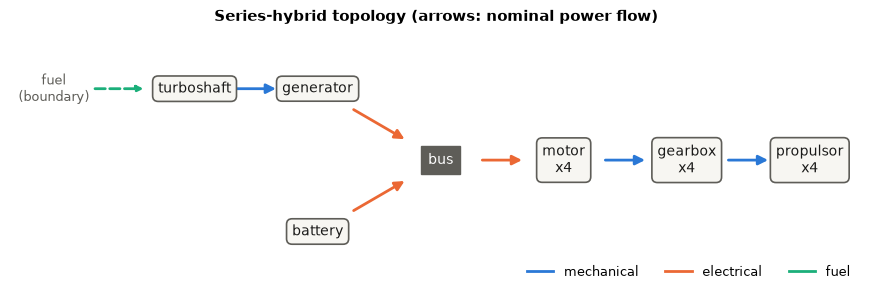

In [35]:
# Network diagram drawn from the topology object itself: positions are layout only.
layout = {"turboshaft": (0, 1), "generator": (1.4, 1), "battery": (1.4, -0.2), "bus": (2.8, 0.4),
          "motor": (4.2, 0.4), "gearbox": (5.6, 0.4), "propulsor": (7.0, 0.4)}
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.set_axis_off()
for name, (x, y) in layout.items():
    label = name if name not in hybrid.instances or hybrid.instances[name].count == 1 \
        else f"{name}\nx{hybrid.instances[name].count}"
    box = dict(boxstyle="round,pad=0.4", fc="#f7f6f2", ec="#5e5d58", lw=1.2) if name != "bus" \
        else dict(boxstyle="square,pad=0.5", fc="#5e5d58", ec="#5e5d58")
    ax.text(x, y, label, ha="center", va="center", fontsize=10, bbox=box,
            color="#ffffff" if name == "bus" else "#1a1a19", zorder=3)
for connection in hybrid.connections:
    source = connection.source.partition(".")[0]
    target = connection.target.partition(".")[0]
    port = hybrid.get_port(connection.source)
    domain = port.domain
    if port.direction is Direction.IN:
        # A consumer on a bus draws power from it: draw the arrow bus -> port.
        source, target = target, source
    ax.add_patch(FancyArrowPatch(layout[source], layout[target], arrowstyle="-|>", mutation_scale=14,
                                 color=domain_colors[domain], lw=2, shrinkA=30, shrinkB=30, zorder=2))
ax.annotate("fuel\n(boundary)", xy=(-0.55, 1), xytext=(-1.6, 1), va="center", ha="center", fontsize=9, color="#5e5d58",
            arrowprops=dict(arrowstyle="-|>", color=domain_colors[Domain.FUEL], lw=2, ls="--"))
for domain, color in domain_colors.items():
    ax.plot([], [], color=color, lw=2, label=domain.value)
ax.legend(loc="lower right", frameon=False, ncol=3)
ax.set(xlim=(-2.1, 7.6), ylim=(-0.7, 1.5), title="Series-hybrid topology (arrows: nominal power flow)")
plt.show()

## 7. Compatibility margins

*From `tier3_compatibility_margins/compatibility_verification.ipynb`.*

In [36]:
import ast
import dataclasses
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import casadi as cas
import matplotlib.pyplot as plt

from aircraft_closure.core.margins import margin_above, margin_below, margin_report
from aircraft_closure.core.ports import ElectricalPortValue, MechanicalPortValue
from aircraft_closure.powertrain.compatibility import (battery_voltage_range_V, design_margins,
                                                       operating_margins, port_envelope)
from aircraft_closure.powertrain.components.battery import Battery
from aircraft_closure.powertrain.components.gearbox import Gearbox
from aircraft_closure.powertrain.components.generator import Generator
from aircraft_closure.powertrain.components.motor import Motor
from aircraft_closure.powertrain.components.propulsor import ActuatorDiskPropulsor
from aircraft_closure.powertrain.components.turboshaft import SimpleTurboshaft
from aircraft_closure.powertrain.ports import port_specs_for
from aircraft_closure.powertrain.topologies import build_series_hybrid
from examples.series_hybrid_point import build_point_problem, solve_topology_point
from examples.series_hybrid_point_explicit import solve_reference_point

check_log = globals().get("check_log", [])


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


def close(a, b, rel=1e-9, abs_tol=1e-12):
    return abs(a - b) <= max(rel * abs(b), abs_tol)


def default_series_hybrid(count_rotors=1, **overrides):
    parts = dict(motor=Motor(), generator=Generator(), battery=Battery(), turboshaft=SimpleTurboshaft(),
                 gearbox=Gearbox(), propulsor=ActuatorDiskPropulsor())
    parts.update(overrides)
    return build_series_hybrid(**parts, count_rotors=count_rotors)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua, critical = "#2a78d6", "#eb6834", "#1baf7a", "#d03b3b"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

### 1. Margin identities

Normalization by the limit makes margins comparable across quantities and units.
A value exactly at its limit gives 0; the sign flips across the limit; margins of
Opti variables are CasADi expressions an optimizer can constrain.

In [37]:
check("identity: value at upper limit -> 0", margin_below("x", 100, 100).value == 0)
check("identity: value at lower limit -> 0", margin_above("x", 400, 400).value == 0)
check("identity: 10 % below upper limit -> +0.1", close(margin_below("x", 90, 100).value, 0.1))
check("identity: 10 % above upper limit -> -0.1", close(margin_below("x", 110, 100).value, -0.1))
check("identity: 10 % above lower limit -> +0.1", close(margin_above("x", 440, 400).value, 0.1))
check("identity: below lower limit is negative", margin_above("x", 360, 400).value < 0)

report = margin_report([margin_below("a", 50, 100), margin_below("b", 120, 100), margin_above("c", 101, 100)])
for entry in report:
    print(f"    {entry.label}: {entry.value:+.3f}  compatible={entry.compatible}")
check("report: sorted most-critical first", [e.label for e in report] == ["b", "c", "a"])
check("report: negative margins flagged incompatible", [e.compatible for e in report] == [False, True, True])

opti = asb.Opti()
power_W = opti.variable(init_guess=50)
margin = margin_below("power", power_W, 100)
opti.minimize(-power_W)
opti.subject_to(margin.value >= 0.25)
solution = opti.solve(verbose=False)
check("symbolic: margin of an Opti variable is CasADi MX", isinstance(margin.value, cas.MX))
check("symbolic: maximizing power with 25 % margin gives 75 W", close(float(solution.value(power_W)), 75, rel=1e-6))
try:
    margin_report([margin_below("power", asb.Opti().variable(init_guess=1), 100)])
    rejected = False
except Exception as error:
    rejected = True
    print(f"    {type(error).__name__}: {str(error)[:80]}")
check("report: unevaluated symbolic margin rejected, never coerced", rejected)

PASS  identity: value at upper limit -> 0
PASS  identity: value at lower limit -> 0
PASS  identity: 10 % below upper limit -> +0.1
PASS  identity: 10 % above upper limit -> -0.1
PASS  identity: 10 % above lower limit -> +0.1
PASS  identity: below lower limit is negative
    b: -0.200  compatible=False
    c: +0.010  compatible=True
    a: +0.500  compatible=True
PASS  report: sorted most-critical first
PASS  report: negative margins flagged incompatible
PASS  symbolic: margin of an Opti variable is CasADi MX
PASS  symbolic: maximizing power with 25 % margin gives 75 W
    RuntimeError: .../casadi/core/mx_node.cpp:205: Can only determine truth value of a numeric MX.
PASS  report: unevaluated symbolic margin rejected, never coerced


### 2. Port envelopes

Each port declares independent bounds. Mechanical ports carry max speed, max
torque and max power separately; no corner point combining them is assumed.
Electrical ports carry a voltage window, or, for the voltage-setting battery,
its achievable terminal-voltage range. Electrical power bounds use shaft ratings
and are therefore loss-free (optimistic for bus capability).

The battery range follows from $V = V_{oc} - I R$ and $V I = P$:
$V_{min} = \tfrac12\left(V_{oc} + \sqrt{V_{oc}^2 - 4 R P_{dis}}\right)$ at max
discharge and $V_{max} = \tfrac12\left(V_{oc} + \sqrt{V_{oc}^2 + 4 R P_{chg}}\right)$
at max charge.

In [38]:
components = [Motor(), Generator(), Battery(), SimpleTurboshaft(), Gearbox(), ActuatorDiskPropulsor()]
for component in components:
    for port in port_specs_for(component):
        print(f"{type(component).__name__:<22}{port.name:<11}{port_envelope(component, port.name)}")

battery = Battery()
min_voltage_V, max_voltage_V = battery_voltage_range_V(battery)
current_discharge_A = (battery.voltage_open_circuit_V - min_voltage_V) / battery.resistance_ohm
current_charge_A = (max_voltage_V - battery.voltage_open_circuit_V) / battery.resistance_ohm
print(f"\nbattery terminal range {min_voltage_V:.2f} .. {max_voltage_V:.2f} V")
check("envelope: discharge root satisfies V I = P_dis",
      close(min_voltage_V * current_discharge_A, battery.max_discharge_power_W, rel=1e-9))
check("envelope: charge root satisfies V I = P_chg",
      close(max_voltage_V * current_charge_A, battery.max_charge_power_W, rel=1e-9))
check("envelope: range brackets open-circuit voltage", min_voltage_V < battery.voltage_open_circuit_V < max_voltage_V)
check("envelope: gearbox output power = rating x efficiency",
      close(port_envelope(Gearbox(), "shaft_out").max_power_W, 97000))
check("envelope: motor shaft declares speed, torque and power independently",
      port_envelope(Motor(), "shaft") == type(port_envelope(Motor(), "shaft"))(1000.0, 500.0, 100000.0))

Motor                 electrical ElectricalEnvelope(min_voltage_V=400.0, max_voltage_V=900.0, max_power_W=100000.0, sets_voltage=False)
Motor                 shaft      MechanicalEnvelope(max_speed_rad_s=1000.0, max_torque_Nm=500.0, max_power_W=100000.0)
Generator             shaft      MechanicalEnvelope(max_speed_rad_s=1000.0, max_torque_Nm=500.0, max_power_W=100000.0)
Generator             electrical ElectricalEnvelope(min_voltage_V=400.0, max_voltage_V=900.0, max_power_W=100000.0, sets_voltage=False)
Battery               electrical ElectricalEnvelope(min_voltage_V=np.float64(793.7003937005906), max_voltage_V=np.float64(803.1128874149274), max_power_W=100000.0, sets_voltage=True)
SimpleTurboshaft      fuel       None
SimpleTurboshaft      shaft      MechanicalEnvelope(max_speed_rad_s=None, max_torque_Nm=None, max_power_W=150000.0)
Gearbox               shaft_in   MechanicalEnvelope(max_speed_rad_s=None, max_torque_Nm=None, max_power_W=100000.0)
Gearbox               shaft_out  Mech

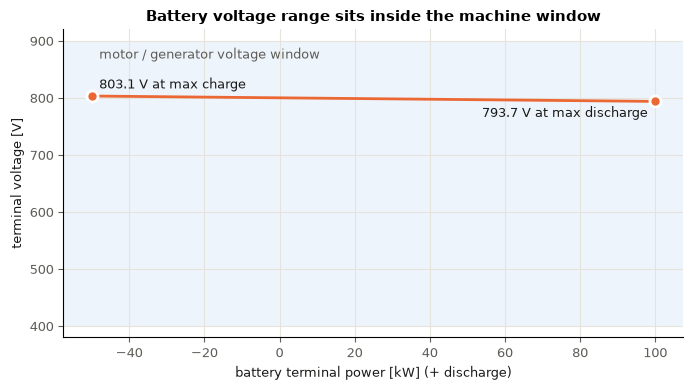

PASS  plot data: polarization line hits both range end points


In [39]:
# Battery polarization line against the motor/generator voltage window.
power_W = np.linspace(-battery.max_charge_power_W, battery.max_discharge_power_W, 300)
# One root covers both quadrants: charging is negative terminal power.
ocv_V, resistance_ohm = battery.voltage_open_circuit_V, battery.resistance_ohm
voltage_V = (ocv_V + np.sqrt(ocv_V**2 - 4 * resistance_ohm * power_W)) / 2
fig, ax = plt.subplots(figsize=(8, 4))
ax.axhspan(Motor().min_voltage_V, Motor().max_voltage_V, color=blue, alpha=0.08, lw=0)
ax.plot(power_W / 1e3, voltage_V, color=orange, lw=2)
ax.plot([-battery.max_charge_power_W / 1e3, battery.max_discharge_power_W / 1e3], [max_voltage_V, min_voltage_V],
        "o", color=orange, ms=8, mec="white", mew=2)
ax.text(-48, Motor().max_voltage_V - 12, "motor / generator voltage window", color=ink_muted, fontsize=9, va="top")
ax.text(battery.max_discharge_power_W / 1e3 - 2, min_voltage_V - 8, f"{min_voltage_V:.1f} V at max discharge",
        ha="right", va="top", fontsize=9, color=ink)
ax.text(-battery.max_charge_power_W / 1e3 + 2, max_voltage_V + 8, f"{max_voltage_V:.1f} V at max charge",
        ha="left", va="bottom", fontsize=9, color=ink)
ax.set(xlabel="battery terminal power [kW] (+ discharge)", ylabel="terminal voltage [V]", ylim=(380, 920),
       title="Battery voltage range sits inside the machine window")
plt.show()
check("plot data: polarization line hits both range end points",
      close(voltage_V[0], max_voltage_V, rel=1e-9) and close(voltage_V[-1], min_voltage_V, rel=1e-9))

### 3. Operating margins at the reference point

The topology example now constrains every operating margin to be $\ge 0$
instead of listing ratings by hand. Its solved margins show where headroom is
smallest: motor shaft power, because the rotor's 89.3 kW is delivered through
a 97 %-efficient gearbox from a 100 kW motor.

In [40]:
opti = asb.Opti()
problem = build_point_problem(opti)
opti.subject_to(problem.rotor.thrust_N == 5000)
solution = opti.solve(verbose=False)
report = margin_report(problem.margins, solution.value)
for entry in report:
    print(f"{entry.label:<28}{float(entry.value):+8.4f}")

check("operating: all margins non-negative at the reference point", all(e.compatible for e in report))
check("operating: motor shaft power is most critical", report[0].label == "motor power_shaft_W")
shaft_power_W = float(solution.value(problem.rotor.shaft_power_W))
check("operating: motor margin = 1 - P_rotor / (eta_gear * P_rated)",
      close(float(report[0].value), 1 - shaft_power_W / 0.97 / 100000, rel=1e-6))
check("operating: 15 margins (5 motor, 5 generator, 2 battery, 1 each for engine, gearbox, rotor)",
      len(problem.margins) == 15)

motor power_shaft_W          +0.0795
gearbox power_input_W        +0.0795
propulsor power_shaft_W      +0.1071
generator max_voltage_V      +0.1124
motor max_voltage_V          +0.1124
generator power_shaft_W      +0.1993
turboshaft power_shaft_W     +0.4662
motor torque_Nm              +0.5398
generator torque_Nm          +0.5996
generator speed_rad_s        +0.6000
motor speed_rad_s            +0.6000
battery discharge_power_W    +0.8082
generator min_voltage_V      +0.9970
motor min_voltage_V          +0.9970
battery charge_power_W       +1.3837
PASS  operating: all margins non-negative at the reference point
PASS  operating: motor shaft power is most critical
PASS  operating: motor margin = 1 - P_rotor / (eta_gear * P_rated)
PASS  operating: 15 margins (5 motor, 5 generator, 2 battery, 1 each for engine, gearbox, rotor)


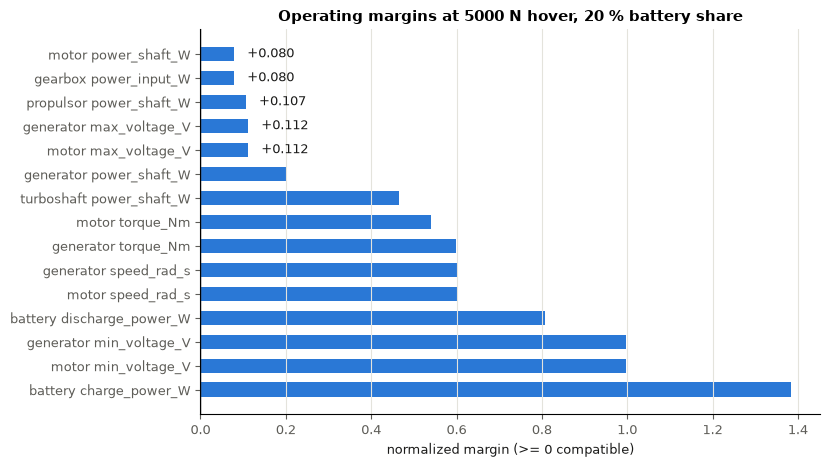

In [41]:
labels = [e.label for e in report][::-1]
values = [float(e.value) for e in report][::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(labels, values, color=[critical if v < 0 else blue for v in values], height=0.6)
ax.axvline(0, color=ink, lw=1)
for y, v in enumerate(values):
    if v < 0.15:
        ax.text(v + 0.03, y, f"{v:+.3f}", va="center", fontsize=9, color=ink)
ax.set(xlabel="normalized margin (>= 0 compatible)", title="Operating margins at 5000 N hover, 20 % battery share")
ax.grid(axis="y", visible=False)
plt.show()

### 4. Design margins of the default series hybrid

Design margins use ratings only. Across a shaft, the downstream port must tolerate
the upstream maximum: `margin_below(upstream max, downstream max)`. On the bus the
battery's voltage range must sit inside each machine's window and loss-free
supply must cover demand (with instance counts).

The default parts are deliberately not matched: the 150 kW turboshaft can overdrive
the 100 kW generator. The report records this as $-0.5$ and leaves the components
unchanged.

In [42]:
default_hybrid = default_series_hybrid()
before = {name: dataclasses.asdict(i.component) for name, i in default_hybrid.instances.items()}
design = margin_report(design_margins(default_hybrid))
for entry in design:
    print(f"{entry.label:<62}{entry.value:+8.4f}")
after = {name: dataclasses.asdict(i.component) for name, i in default_hybrid.instances.items()}

design_values = {e.label: e.value for e in design}
check("design: turboshaft 150 kW vs generator 100 kW gives -0.5",
      close(design_values["turboshaft.shaft->generator.shaft max_power_W"], -0.5))
check("design: motor 100 kW into gearbox 100 kW gives 0",
      close(design_values["motor.shaft->gearbox.shaft_in max_power_W"], 0.0))
check("design: gearbox 97 kW output into 100 kW rotor gives +0.03",
      close(design_values["gearbox.shaft_out->propulsor.shaft max_power_W"], 0.03))
check("design: loss-free bus supply 200 kW vs demand 100 kW gives +1",
      close(design_values["bus power_W (loss-free)"], 1.0))
check("design: battery range inside both machine windows",
      all(v >= 0 for k, v in design_values.items() if "voltage" in k))
check("design: no speed/torque margin where only one side declares it",
      not any("speed" in k or "torque" in k for k in design_values))
check("design: margins never modify components", before == after)

four = {m.label: m.value for m in design_margins(default_series_hybrid(count_rotors=4))}
check("design: four rotor strings double-overload the bus ((200 - 400) / 400)",
      close(four["bus power_W (loss-free)"], -0.5))
low_voltage = {m.label: m.value for m in design_margins(
    default_series_hybrid(battery=Battery(voltage_open_circuit_V=410.0)))}
print(f"\n410 V pack min-voltage margin vs motor: "
      f"{low_voltage['bus battery.electrical->motor.electrical min_voltage_V']:+.4f}")
check("design: a 410 V pack sags below the 400 V motor minimum at max discharge",
      low_voltage["bus battery.electrical->motor.electrical min_voltage_V"] < 0)

turboshaft.shaft->generator.shaft max_power_W                  -0.5000
motor.shaft->gearbox.shaft_in max_power_W                      +0.0000
gearbox.shaft_out->propulsor.shaft max_power_W                 +0.0300
bus battery.electrical->generator.electrical max_voltage_V     +0.1077
bus battery.electrical->motor.electrical max_voltage_V         +0.1077
bus battery.electrical->generator.electrical min_voltage_V     +0.9843
bus battery.electrical->motor.electrical min_voltage_V         +0.9843
bus power_W (loss-free)                                        +1.0000
PASS  design: turboshaft 150 kW vs generator 100 kW gives -0.5
PASS  design: motor 100 kW into gearbox 100 kW gives 0
PASS  design: gearbox 97 kW output into 100 kW rotor gives +0.03
PASS  design: loss-free bus supply 200 kW vs demand 100 kW gives +1
PASS  design: battery range inside both machine windows
PASS  design: no speed/torque margin where only one side declares it
PASS  design: margins never modify components
PASS  desi

## 8. Electrical layer

*From `tier15_electrical/electrical_verification.ipynb`.*

In [43]:
import sys
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from aircraft_closure.powertrain.components.cable import Cable, PartialDischargeModel, pressure_ratio
from aircraft_closure.powertrain.components.converters import ConverterLossModel, Inverter
from aircraft_closure.powertrain.components.motor import Motor, TorqueDensityMassModel
from aircraft_closure.powertrain.components.protection import ProtectionUnit
from examples.halo_sizing import (HaloAssumptions, HaloRequirements, assumptions_tier15, bus_voltage_window,
                                  enumerate_bus_voltage, solve_halo_sizing)

# Plan 035 changed the defaults (drag corrections, redundancy, unit-built machines, gearbox stages); this notebook
# keeps reproducing its own tier on the plan 030 settings.
from functools import partial
from examples.halo_sizing import HaloAssumptions as _HaloAssumptions, solve_halo_sizing as _solve_halo_sizing
from examples.halo_sizing import pre_layout, pre_plan035 as _pre_plan035
HaloAssumptions = partial(_HaloAssumptions, **_pre_plan035, **pre_layout)
solve_halo_sizing = partial(_solve_halo_sizing, assumptions=HaloAssumptions())

check_log = globals().get("check_log", [])


def check(name, passed):
    # Record and print one named verification.
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua, yellow = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
ramp = ["#0d366b", "#184f95", "#256abf", "#3987e5", "#6da7ec", "#9ec5f4"]
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": ink_muted,
                     "axes.labelcolor": ink, "xtick.color": ink_muted, "ytick.color": ink_muted,
                     "axes.grid": True, "grid.color": grid_color, "figure.dpi": 110})
electrical_names = ("inverter_motor", "inverter_generator", "cable_motor", "cable_generator", "cable_battery",
                    "protection_motor", "protection_generator", "protection_battery", "dcdc")

### 1. Converter losses

$P_{loss} = L_r\,[f_0 + f_s |P|/P_r + f_c (P/P_r)^2 (V_r/V)^2]$ with $L_r = P_r(1-\eta_r)/\eta_r$
(conduction 0.5, switching 0.4, fixed 0.1 at rated). Efficiency is exactly η_r at the rated point, peaks
at $|P|/P_r = \sqrt{f_0/f_c} = 0.45$, and falls as the DC link sags (more current for the same power).
Positive power flows DC → AC; a rectifier sees negative power, with the same loss.

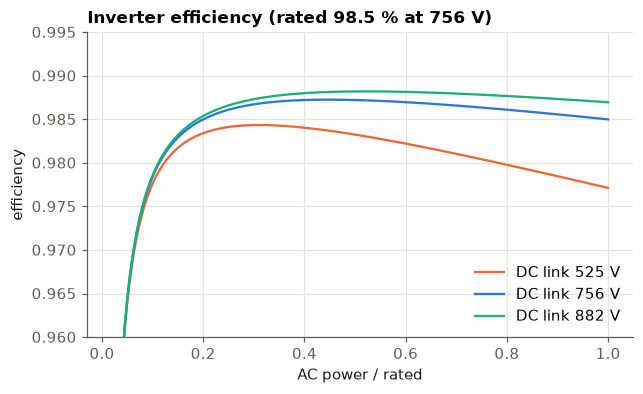

PASS  converter: efficiency = 98.5 % at rated power and voltage
PASS  converter: peak efficiency at sqrt(f0/fc) = 0.447 of rated
PASS  converter: rectifier and motoring losses equal (sign convention)
PASS  converter: lower DC voltage gives more loss at the same power
PASS  converter: 600 kW inverter weighs 30 kg at 20 kW/kg


In [44]:
model = ConverterLossModel(efficiency_rated=0.985, voltage_rated_V=756.0)
inverter = Inverter(power_rated_W=600e3, loss_model=model)
loads = np.linspace(0.02, 1.0, 200)
fig, ax = plt.subplots(figsize=(6.4, 3.6))
for voltage_V, color in ((525.0, orange), (756.0, blue), (882.0, aqua)):
    eff = [inverter.evaluate(x * 600e3, voltage_V).power_ac_W / inverter.evaluate(x * 600e3, voltage_V).power_dc_W
           for x in loads]
    ax.plot(loads, eff, color=color, label=f"DC link {voltage_V:.0f} V")
ax.set_xlabel("AC power / rated"); ax.set_ylabel("efficiency"); ax.set_ylim(0.96, 0.995); ax.legend(frameon=False)
ax.set_title("Inverter efficiency (rated 98.5 % at 756 V)", loc="left"); plt.show()

rated = inverter.evaluate(600e3, 756.0)
check("converter: efficiency = 98.5 % at rated power and voltage", abs(rated.power_ac_W / rated.power_dc_W - 0.985) < 1e-5)
eff_756 = [x / (x + model.evaluate(x * 600e3, 756.0, 600e3) / 600e3) for x in loads]
check("converter: peak efficiency at sqrt(f0/fc) = 0.447 of rated", abs(loads[int(np.argmax(eff_756))] - 0.447) < 0.01)
check("converter: rectifier and motoring losses equal (sign convention)",
      abs(inverter.evaluate(-3e5, 756.0).power_loss_W - inverter.evaluate(3e5, 756.0).power_loss_W) < 1e-9)
check("converter: lower DC voltage gives more loss at the same power",
      inverter.evaluate(5e5, 525.0).power_loss_W > inverter.evaluate(5e5, 882.0).power_loss_W)
check("converter: 600 kW inverter weighs 30 kg at 20 kW/kg", abs(inverter.get_mass() - 30.0) < 1e-9)

### 2. Cables and partial discharge

Conductor area = design current / 3 A/mm² (aluminium), loop resistance ρ L n / A. The insulation wall is
the smooth maximum of 0.25 mm and the wall at which Dakin's inception voltage at the ceiling pressure
equals 1.5 × the peak voltage. For a feeder carrying a fixed power, the conductor shrinks as 1/V while the
insulation grows about as V^2.2, so the cable mass falls with voltage until the insulation term catches up.

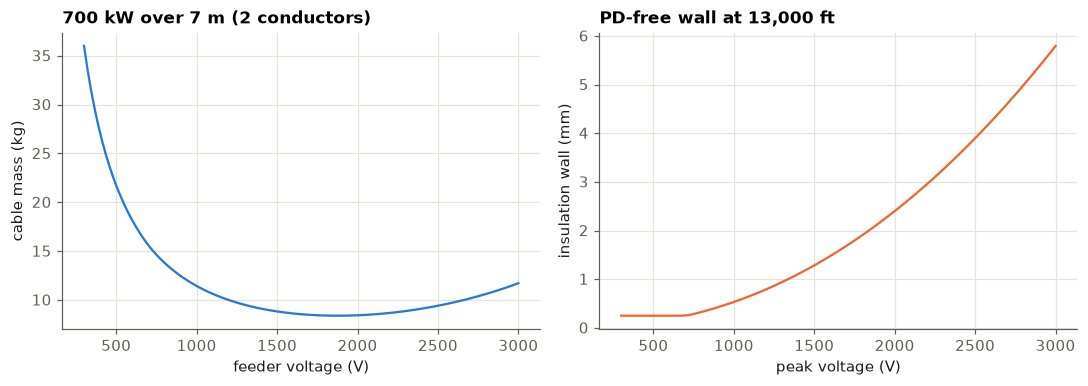

PASS  cable: PD thickness round trip (PDIV = 1.5 x peak at the design pressure)
PASS  cable: insulation wall grows with voltage
PASS  cable: mass at fixed power falls from 300 V to 1,000 V
PASS  cable: rated loss fraction = rho J L_total / V
PASS  cable: PDIV at the ceiling is lower than at sea level
PASS  protection: 2 x (0.2 + 1.3) kg and 0.3 V at 1,000 A


In [45]:
pd = PartialDischargeModel()
voltages_V = np.linspace(300.0, 3000.0, 120)
ceiling_m = HaloRequirements().altitude_ceiling_m
power_W, length_m = 700e3, 7.0
cables = [Cable(length_m=length_m, max_current_A=power_W / v, max_voltage_V=v, altitude_design_m=ceiling_m)
          for v in voltages_V]
mass_kg = np.array([c.get_mass() for c in cables])
thickness_mm = np.array([c.thickness_insulation_m() * 1e3 for c in cables])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(voltages_V, mass_kg, color=blue)
axes[0].set_xlabel("feeder voltage (V)"); axes[0].set_ylabel("cable mass (kg)")
axes[0].set_title(f"{power_W/1e3:.0f} kW over {length_m:.0f} m (2 conductors)", loc="left")
axes[1].plot(voltages_V, thickness_mm, color=orange)
axes[1].set_xlabel("peak voltage (V)"); axes[1].set_ylabel("insulation wall (mm)")
axes[1].set_title("PD-free wall at 13,000 ft", loc="left"); plt.tight_layout(); plt.show()

check("cable: PD thickness round trip (PDIV = 1.5 x peak at the design pressure)",
      abs(pd.voltage_inception_V(pd.thickness_required_m(1000.0, 2.5, 0.6), 2.5, 0.6) - 1500.0) < 1e-6)
check("cable: insulation wall grows with voltage", np.all(np.diff(thickness_mm) >= -1e-9))
check("cable: mass at fixed power falls from 300 V to 1,000 V", cables[0].get_mass() > Cable(
    length_m=length_m, max_current_A=power_W / 1000.0, max_voltage_V=1000.0, altitude_design_m=ceiling_m).get_mass())
c = Cable(length_m=8.0, max_current_A=1000.0, max_voltage_V=800.0)
check("cable: rated loss fraction = rho J L_total / V",
      abs(c.evaluate(1000.0).power_loss_W / 8e5 - 3.4e-8 * 3e6 * 16 / 800) < 1e-12)
check("cable: PDIV at the ceiling is lower than at sea level",
      c.voltage_inception_V(pressure_ratio(ceiling_m)) < c.voltage_inception_V(1.0))
p = ProtectionUnit(max_current_A=1000.0)
check("protection: 2 x (0.2 + 1.3) kg and 0.3 V at 1,000 A",
      abs(p.get_mass() - 3.0) < 1e-12 and abs(p.evaluate(1000.0).voltage_drop_V - 0.3) < 1e-12)

### 3. Splitting the inverter out of the machine

Tier 13 used 15 N.m/kg (magniX magni350/650, *including* inverters and cables) with a 10 kW/kg high-speed
cap. With a separate 20 kW/kg inverter, the bare-machine figures that keep the same integrated mass where
Tier 13 was anchored are

* torque density: 1/15 = 1/τ_bare + 200 rad/s / 20 kW/kg → τ_bare = 17.6 N.m/kg (magniX at its speed);
* high-speed cap: 1/10 = 1/20 + 1/20 → 20 kW/kg bare.

So the default aircraft does not jump through the machine split itself; it moves only through what is new
(cables, protection, converter losses). The implied 20 kW/kg bare cap is above NASA's HEMM 16 kW/kg
electromagnetic target: the Tier 13 cap was optimistic, and a sensitivity with a 10 kW/kg *bare* cap is in
section 6.

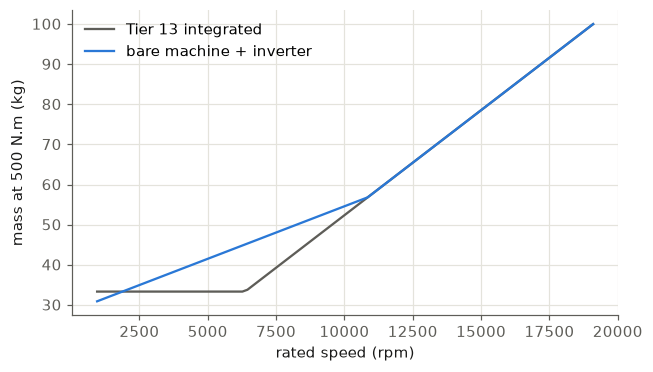

PASS  machine split: same integrated mass at magniX speed (200 rad/s) within 0.5 %
PASS  machine split: same integrated mass on the high-speed cap (Halo machines, ~1,400 rad/s)


In [46]:
speeds_rad_s = np.linspace(100.0, 2000.0, 100)
torque_Nm = 500.0
integrated = TorqueDensityMassModel(15.0, 10000.0, smoothing_kg=1e-6)
bare = TorqueDensityMassModel(17.6, 20000.0, smoothing_kg=1e-6)
m_int = np.array([integrated.mass_kg(Motor(power_rated_W=torque_Nm * w, max_torque_Nm=torque_Nm)) for w in speeds_rad_s])
m_split = np.array([bare.mass_kg(Motor(power_rated_W=torque_Nm * w, max_torque_Nm=torque_Nm)) + torque_Nm * w / 20000.0
                    for w in speeds_rad_s])
fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(speeds_rad_s * 60 / (2 * np.pi), m_int, color=ink_muted, label="Tier 13 integrated")
ax.plot(speeds_rad_s * 60 / (2 * np.pi), m_split, color=blue, label="bare machine + inverter")
ax.set_xlabel("rated speed (rpm)"); ax.set_ylabel(f"mass at {torque_Nm:.0f} N.m (kg)"); ax.legend(frameon=False)
plt.show()
at = lambda w: (integrated.mass_kg(Motor(power_rated_W=torque_Nm * w, max_torque_Nm=torque_Nm)),
                bare.mass_kg(Motor(power_rated_W=torque_Nm * w, max_torque_Nm=torque_Nm)) + torque_Nm * w / 2e4)
check("machine split: same integrated mass at magniX speed (200 rad/s) within 0.5 %",
      abs(at(200.0)[1] / at(200.0)[0] - 1) < 0.005)
check("machine split: same integrated mass on the high-speed cap (Halo machines, ~1,400 rad/s)",
      abs(at(1400.0)[1] / at(1400.0)[0] - 1) < 1e-6)

## 9. Redundancy

*From `tier18_redundancy/redundancy_verification.ipynb`.*

In [47]:
import sys
import time
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
for path in (repo_root / "src", repo_root):     # this checkout's package even if another one is installed
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import aerosandbox as asb
import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from aircraft_closure.core.ports import MechanicalPortValue
from aircraft_closure.core.topology import connection_residuals
from aircraft_closure.performance.flight_point import FlightCondition
from aircraft_closure.powertrain.components.battery_ecm import EquivalentCircuitBattery
from aircraft_closure.powertrain.components.thermal import LumpedThermalModel
from aircraft_closure.powertrain.redundancy import battery_with_strings, degraded_state
from aircraft_closure.thermal.heat import thermal_parameters
from examples.halo_sizing import HaloAssumptions, assumptions_tier18, build_halo_aircraft, solve_halo_sizing

# Plan 035 changed the defaults (drag corrections, redundancy, unit-built machines, gearbox stages); this notebook
# keeps reproducing its own tier on the plan 030 settings.
from functools import partial
from examples.halo_sizing import HaloAssumptions as _HaloAssumptions, solve_halo_sizing as _solve_halo_sizing
from examples.halo_sizing import pre_layout, pre_plan035 as _pre_plan035
HaloAssumptions = partial(_HaloAssumptions, **_pre_plan035, **pre_layout)
solve_halo_sizing = partial(_solve_halo_sizing, assumptions=HaloAssumptions())
from tests.integration.test_halo_thermal import numeric_design
from tests.performance.test_flight_point_redundancy import (redundant_aircraft, solve, string_contactor, tie_cable,
                                                            tie_contactor)

check_log = globals().get("check_log", [])


def check(name, passed):
    # Record and print one named verification.
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua, yellow, violet = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#8a5cd6"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8,
                     "axes.labelcolor": ink, "xtick.color": ink_muted, "ytick.color": ink_muted})

### 1. Architecture in the topology: combiners, bus copies, ties and strings

A combiner joins N lane motors to one gearbox input (speed equal, N x lane torque = gearbox torque); the pack is
split into string contactors the same way. All ones builds the plain topology.

In [48]:
plain = build_halo_aircraft(numeric_design(), assumptions=HaloAssumptions())
ones = build_halo_aircraft(numeric_design(), assumptions=HaloAssumptions(
    redundancy=True, count_lanes_motor=1, count_buses=1, count_strings_battery=1))
redundant = build_halo_aircraft(replace(numeric_design(), torque_peak_motor_Nm=200.0), assumptions=assumptions_tier18)
t = redundant.powertrain.topology
print(f"{'instance':<22}{'plain':>7}{'2/2/2':>7}")
for name, instance in t.instances.items():
    count_plain = plain.powertrain.topology.instances[name].count if name in plain.powertrain.topology.instances else 0
    print(f"{name:<22}{count_plain:7d}{instance.count:7d}")
print("bus copies:", t.buses["bus"].count, "| combined connections:",
      [(c.source, c.target) for c in t.connections if c.combine])
check("all ones builds the plain topology", plain.powertrain.topology.connections == ones.powertrain.topology.connections
      and {n: i.count for n, i in plain.powertrain.topology.instances.items()}
      == {n: i.count for n, i in ones.powertrain.topology.instances.items()})
from aircraft_closure.core.topology import Topology
from aircraft_closure.core.ports import PortSpec, Domain, Direction
toy = Topology()
toy.add("motor", object(), (PortSpec("shaft", Domain.MECHANICAL, Direction.OUT),), count=4)
toy.add("gearbox", object(), (PortSpec("shaft", Domain.MECHANICAL, Direction.IN),), count=2)
toy.connect("motor.shaft", "gearbox.shaft", combine=True)
r = {x.label: x.value for x in connection_residuals(toy, {"motor.shaft": MechanicalPortValue(400.0, 150.0),
                                                           "gearbox.shaft": MechanicalPortValue(400.0, 300.0)})}
check("combiner: two lanes of 150 N.m balance a 300 N.m gearbox input", all(v == 0 for v in r.values()))

instance                plain  2/2/2
turboshaft                  2      2
generator                   2      2
battery                     1      1
motor                       2      4
gearbox                     2      2
propulsor                   2      2
generator_gearbox           2      2
protection_string           0      2
protection_bus_tie          0      1
cable_bus_tie               0      1
bus copies: 2 | combined connections: [('battery.electrical', 'protection_string.input'), ('motor.shaft', 'gearbox.shaft_in')]
PASS  all ones builds the plain topology
PASS  combiner: two lanes of 150 N.m balance a 300 N.m gearbox input


### 2. Multiplicity masses

With the torque-density machine mass (linear in torque) N lanes at 1/N of the torque weigh one machine, so lanes
cost mass only through the failure cases (and, with the Tier 15 layer, per-lane feeder overheads). Ties and
string contactors are the components times their counts.

In [49]:
def masses(aircraft):
    return {i.instance_name: float(i.mass_properties.mass) for i in aircraft.powertrain.get_instance_mass_properties()}

m_plain, m_red = masses(plain), masses(redundant)
print(f"motors: plain {m_plain['motor']:.1f} kg (2 x 400 N.m), 2 lanes x 2 rotors at 200 N.m {m_red['motor']:.1f} kg")
# The smooth maximum in the mass model adds at most 2 kg x ln 2 per machine, so 4 lanes vs 2 machines differ by
# at most 4 x 1.39 kg.
check("two half-torque lanes weigh one machine (within the softmax smoothing)",
      abs(m_red["motor"] - m_plain["motor"]) <= 4 * 2.0 * np.log(2))
for name in ("protection_string", "protection_bus_tie", "cable_bus_tie"):
    inst = t.instances[name]
    check(f"{name}: installed mass = count x component mass",
          abs(m_red[name] - inst.count * float(inst.component.get_mass())) < 1e-9)
    print(f"  {name}: {inst.count} x {float(inst.component.get_mass()):.2f} kg, rated "
          f"{float(inst.component.max_current_A):.0f} A")
with_layer = masses(build_halo_aircraft(replace(numeric_design(), torque_peak_motor_Nm=400.0 / 2),
                                        assumptions=replace(assumptions_tier18, electrical_layer=True)))
plain_layer = masses(build_halo_aircraft(numeric_design(), assumptions=HaloAssumptions(electrical_layer=True)))
over_kg = sum(with_layer[n] - plain_layer[n] for n in ("cable_motor", "protection_motor", "inverter_motor"))
print(f"with the Tier 15 layer, lane feeders (inverters, cables, contactors) add {over_kg:.1f} kg at the same torque")
check("with the layer, per-lane feeders cost mass (fixed contactor and insulation terms)", over_kg > 0)

motors: plain 138.8 kg (2 x 400 N.m), 2 lanes x 2 rotors at 200 N.m 141.3 kg
PASS  two half-torque lanes weigh one machine (within the softmax smoothing)
PASS  protection_string: installed mass = count x component mass
  protection_string: 2 x 1.86 kg, rated 560 A
PASS  protection_bus_tie: installed mass = count x component mass
  protection_bus_tie: 1 x 7.71 kg, rated 2811 A
PASS  cable_bus_tie: installed mass = count x component mass
  cable_bus_tie: 1 x 12.50 kg, rated 2811 A
with the Tier 15 layer, lane feeders (inverters, cables, contactors) add 1.7 kg at the same torque
PASS  with the layer, per-lane feeders cost mass (fixed contactor and insulation terms)


### 3. Degraded flight points (four-rotor reference)

Lane out: the surviving lane carries the gearbox torque; bus out: the tie carries the failed bus's share; string
out: the pack's limits and sag are those of the remaining strings.

 lanes  lane kW  motors kW  lane-out lane kW  lane-out motors kW
     1     61.2      254.9               nan                 nan
     2     30.6      254.9              61.2               255.0
     3     20.4      254.9              30.6               254.9
     4     15.3      254.9              20.4               254.9
PASS  healthy lanes draw exactly one machine's power
PASS  lane out: each surviving lane carries ~N/(N-1) of its healthy share
PASS  lane out, N = 2: copper x N/(N-1), spinning loss x (N-1)/N
PASS  lane out, N = 3: copper x N/(N-1), spinning loss x (N-1)/N
PASS  lane out, N = 4: copper x N/(N-1), spinning loss x (N-1)/N
PASS  bus out: tie current = motor demand / (2 x bus voltage)
PASS  bus out: tie loss = I^2 (R_contactor + R_cable)
bus out: 1 lane per rotor, tie 160 A, loss 30 W
PASS  string out: half the strings, half the current rating and capacity
PASS  string out: thermal time constant unchanged (C x 1/2, R x 2)


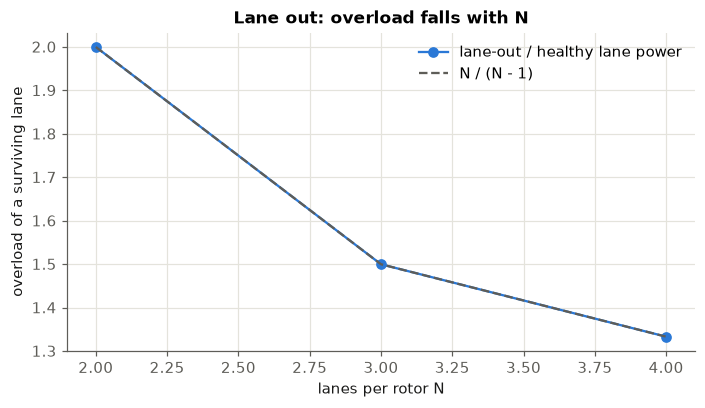

In [50]:
rows = []
for lanes_total in (1, 2, 3, 4):
    aircraft = redundant_aircraft(count_lanes=lanes_total)
    healthy, s0 = solve(aircraft)
    row = dict(lanes=lanes_total, healthy_lane_kW=float(s0.value(healthy.speed_motor_rad_s * healthy.torque_motor_Nm)) / 1e3,
               healthy_motors_kW=float(s0.value(healthy.power_electric_motors_W)) / 1e3)
    if lanes_total > 1:
        out, s1 = solve(aircraft, FlightCondition(mode="hover", altitude_m=0.0, label="lane out",
                                                  active_lane_count=lanes_total - 1))
        row.update(out_lane_kW=float(s1.value(out.speed_motor_rad_s * out.torque_motor_Nm)) / 1e3,
                   out_motors_kW=float(s1.value(out.power_electric_motors_W)) / 1e3)
    rows.append(row)
print(f"{'lanes':>6}{'lane kW':>9}{'motors kW':>11}{'lane-out lane kW':>18}{'lane-out motors kW':>20}")
for r in rows:
    print(f"{r['lanes']:6d}{r['healthy_lane_kW']:9.1f}{r['healthy_motors_kW']:11.1f}"
          f"{r.get('out_lane_kW', float('nan')):18.1f}{r.get('out_motors_kW', float('nan')):20.1f}")
check("healthy lanes draw exactly one machine's power", all(abs(r["healthy_motors_kW"] / rows[0]["healthy_motors_kW"] - 1)
                                                         < 1e-6 for r in rows))
check("lane out: each surviving lane carries ~N/(N-1) of its healthy share",
      all(abs(r["out_lane_kW"] / r["healthy_lane_kW"] / (r["lanes"] / (r["lanes"] - 1)) - 1) < 0.03 for r in rows[1:]))
# Loss split at equal speed and rotor torque (McDonald, rubber lanes): the active lanes' copper loss C3 Q^2 rises by
# N / (N - 1), while the speed-dependent loss (C0 + C1 w + C2 w^3) falls by (N - 1) / N because the failed lane is
# declutched (a freewheel per lane, assumed) and no longer spins. Net loss can therefore fall slightly (table).
from aircraft_closure.powertrain.components.motor import Motor
from tests.performance.test_flight_point_redundancy import lane_of
speed_rad_s, torque_Nm = 400.0, 300.0
for lanes_total in (2, 3, 4):
    lane = lane_of(Motor(), lanes_total)
    c = lane.loss_model.coefficients()
    copper = lambda active: active * c.torque_W_Nm2 * (torque_Nm / active)**2
    spinning = lambda active: active * (c.constant_W + c.linear_W_s_rad * speed_rad_s + c.cubic_W_s3_rad3 * speed_rad_s**3)
    total = lambda active: active * lane.loss_model.evaluate(speed_rad_s, torque_Nm / active, 800.0)
    ok = (abs(copper(lanes_total - 1) / copper(lanes_total) - lanes_total / (lanes_total - 1)) < 1e-12
          and abs(spinning(lanes_total - 1) / spinning(lanes_total) - (lanes_total - 1) / lanes_total) < 1e-12
          and abs(total(lanes_total - 1) - copper(lanes_total - 1) - spinning(lanes_total - 1)) < 1e-9)
    check(f"lane out, N = {lanes_total}: copper x N/(N-1), spinning loss x (N-1)/N", ok)

aircraft = redundant_aircraft(count_lanes=2, count_buses=2)
bus, s = solve(aircraft, FlightCondition(mode="hover", altitude_m=0.0, label="bus out", count_buses_failed=1))
current_A = float(s.value(bus.redundancy.current_tie_A))
check("bus out: tie current = motor demand / (2 x bus voltage)",
      abs(current_A - float(s.value(bus.power_electric_motors_W / (2 * bus.battery.voltage_V)))) < 1e-6)
loss_W = float(s.value(bus.redundancy.power_loss_tie_W))
check("bus out: tie loss = I^2 (R_contactor + R_cable)",
      abs(loss_W - current_A**2 * (tie_contactor.resistance_ohm() + tie_cable.resistance_ohm())) < 1e-6)
print(f"bus out: {bus.redundancy.count_lanes_active} lane per rotor, tie {current_A:.0f} A, loss {loss_W:.0f} W")

pack = EquivalentCircuitBattery(count_parallel=20.0, thermal_model=LumpedThermalModel(1000.0, 60.0, 25.0))
half = battery_with_strings(pack, 0.5)
check("string out: half the strings, half the current rating and capacity",
      abs(half.get_limits().max_discharge_current_A / pack.get_limits().max_discharge_current_A - 0.5) < 1e-12
      and abs(half.energy_capacity_J / pack.energy_capacity_J - 0.5) < 1e-12)
p_full, p_half = thermal_parameters(pack), thermal_parameters(half)
check("string out: thermal time constant unchanged (C x 1/2, R x 2)",
      abs(p_full.capacity_J_K * p_full.resistance_K_W - p_half.capacity_J_K * p_half.resistance_K_W) < 1e-9)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
n = [r["lanes"] for r in rows[1:]]
ax.plot(n, [r["out_lane_kW"] / r["healthy_lane_kW"] for r in rows[1:]], "o-", color=blue, label="lane-out / healthy lane power")
ax.plot(n, [k / (k - 1) for k in n], "--", color=ink_muted, label="N / (N - 1)")
ax.set(xlabel="lanes per rotor N", ylabel="overload of a surviving lane", title="Lane out: overload falls with N")
ax.legend(frameon=False)
plt.tight_layout()

## 10. Thermal

*From `tier19_thermal/thermal_verification.ipynb`.*

In [51]:
import sys
import time
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
for path in (repo_root / "src", repo_root):     # this checkout's package even if another one is installed
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import aerosandbox as asb
import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from aircraft_closure.powertrain.components.heat_exchanger import RamAirHeatExchanger
from aircraft_closure.powertrain.components.thermal import LumpedThermalModel
from examples.halo_sizing import HaloAssumptions, solve_halo_sizing

# Plan 030 made the thermal model the default; this notebook keeps comparing against the thermal-off plan 027
# reference (13,639 lb).
from functools import partial
from examples.halo_sizing import HaloAssumptions as _HaloAssumptions, solve_halo_sizing as _solve_halo_sizing
HaloAssumptions = partial(_HaloAssumptions, drag_corrections=False, redundancy=False, machine_mass_model="torque_density", gearbox_stages=False,
                          thermal_model=False)
solve_halo_sizing = partial(_solve_halo_sizing, assumptions=HaloAssumptions())

check_log = globals().get("check_log", [])


def check(name, passed):
    # Record and print one named verification.
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua, yellow = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8,
                     "axes.labelcolor": ink, "xtick.color": ink_muted, "ytick.color": ink_muted})

### 1. Lumped capacitance: closed form, steady state and short-time ratings

T(t) = T_ss + (T_0 - T_ss) e^(-t/tau) with T_ss = T_c + Q R and tau = R C. R is set so that the continuous loss
holds the machine exactly at the limit (150 C over a 60 C coolant). A hold of duration t from the coolant
temperature then allows Q / Q_cont = 1 / (1 - e^(-t/tau)).

PASS  steady state at the continuous loss is the 150 C limit
PASS  one time constant covers 1 - 1/e of the rise
PASS  None start is the steady state
PASS  zero loss relaxes to the coolant
PASS  two 30 s intervals equal one 60 s interval (exact propagation)


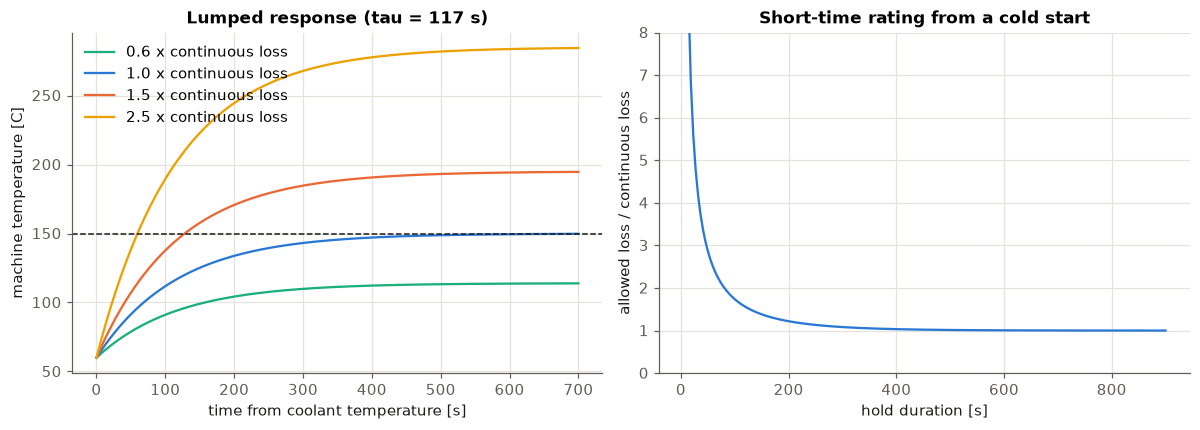

In [52]:
model = LumpedThermalModel()
capacity_J_K, loss_continuous_W = 500.0 * 70.0, 27000.0          # a ~70 kg machine, ~27 kW continuous loss
resistance_K_W = (model.temperature_max_C - model.temperature_coolant_C) / loss_continuous_W
tau_s = capacity_J_K * resistance_K_W
time_s = np.linspace(0, 6 * tau_s, 300)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for ratio, color in ((0.6, aqua), (1.0, blue), (1.5, orange), (2.5, yellow)):
    temperature_C = model.temperature_end_C(ratio * loss_continuous_W, time_s, capacity_J_K, resistance_K_W, 60.0)
    ax1.plot(time_s, temperature_C, color=color, label=f"{ratio:.1f} x continuous loss")
ax1.axhline(model.temperature_max_C, color=ink, lw=1, ls="--")
ax1.set(xlabel="time from coolant temperature [s]", ylabel="machine temperature [C]",
        title=f"Lumped response (tau = {tau_s:.0f} s)")
ax1.legend(frameon=False)
duration_s = np.linspace(5, 900, 200)
ax2.plot(duration_s, 1 / (1 - np.exp(-duration_s / tau_s)), color=blue)
ax2.set(xlabel="hold duration [s]", ylabel="allowed loss / continuous loss", ylim=(0, 8),
        title="Short-time rating from a cold start")
plt.tight_layout()

steady = model.temperature_end_C(loss_continuous_W, 1e7, capacity_J_K, resistance_K_W, 60.0)
check("steady state at the continuous loss is the 150 C limit", abs(steady - 150.0) < 1e-9)
one_tau = model.temperature_end_C(loss_continuous_W, tau_s, capacity_J_K, resistance_K_W, 60.0)
check("one time constant covers 1 - 1/e of the rise", abs((one_tau - 60) / 90 - (1 - np.exp(-1))) < 1e-12)
check("None start is the steady state", abs(model.temperature_end_C(loss_continuous_W, 60.0, capacity_J_K,
                                                                    resistance_K_W) - 150.0) < 1e-12)
check("zero loss relaxes to the coolant", abs(model.temperature_end_C(0.0, 1e7, capacity_J_K, resistance_K_W,
                                                                      140.0) - 60.0) < 1e-9)
half = model.temperature_end_C(2 * loss_continuous_W, 30.0, capacity_J_K, resistance_K_W, 60.0)
check("two 30 s intervals equal one 60 s interval (exact propagation)",
      abs(model.temperature_end_C(2 * loss_continuous_W, 30.0, capacity_J_K, resistance_K_W, half)
          - model.temperature_end_C(2 * loss_continuous_W, 60.0, capacity_J_K, resistance_K_W, 60.0)) < 1e-9)

### 2. Ram-air heat exchanger: cooling drag, fan power and the hot day

Air flow m = Q / (eps cp dT) with dT = T_coolant - T_ambient; pressure loss dp_ref (m/m_ref)^2 rho_ref/rho;
pumping power m dp / rho, so drag and fan power grow as Q^3 / (dT^3 Q_rated^2). The required rating is
Q x 40 K / dT, so the 4,000 ft / 95 F hover (dT = 25 K) needs 1.6 x its heat.

PASS  zero heat: zero flow, drag and fan power
PASS  drag ~ heat^3
PASS  ram drag x speed = pumping power
PASS  hot day: required rating = heat x 40 K / dT
hot day dT 25.0 K: 100 kW needs a 160 kW rating and 11.9 kW of fan power at the 150 kW cooler


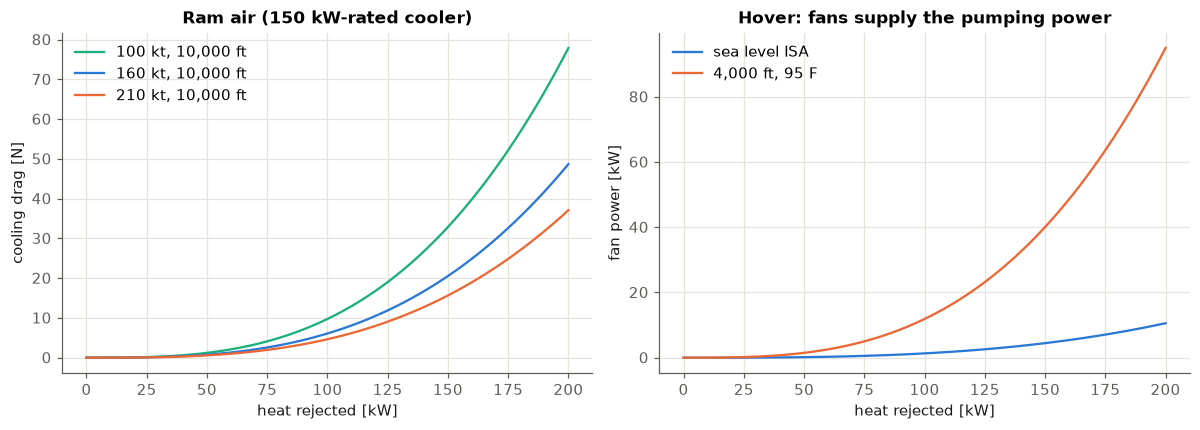

In [53]:
exchanger = RamAirHeatExchanger(power_rated_W=150e3)
cruise_atmosphere = asb.Atmosphere(altitude=10000 * u.foot)
hot = asb.Atmosphere(altitude=4000 * u.foot, temperature_deviation=27.7)
heat_W = np.linspace(0, 200e3, 101)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for velocity_kt, color in ((100, aqua), (160, blue), (210, orange)):
    r = exchanger.evaluate(heat_W, cruise_atmosphere, velocity_kt * u.knot)
    ax1.plot(heat_W / 1e3, r.drag_N, color=color, label=f"{velocity_kt} kt, 10,000 ft")
ax1.set(xlabel="heat rejected [kW]", ylabel="cooling drag [N]", title="Ram air (150 kW-rated cooler)")
ax1.legend(frameon=False)
for atmosphere, label, color in ((asb.Atmosphere(altitude=0), "sea level ISA", blue), (hot, "4,000 ft, 95 F", orange)):
    r = exchanger.evaluate(heat_W, atmosphere, 0.0, fan=True)
    ax2.plot(heat_W / 1e3, r.power_fan_W / 1e3, color=color, label=label)
ax2.set(xlabel="heat rejected [kW]", ylabel="fan power [kW]", title="Hover: fans supply the pumping power")
ax2.legend(frameon=False)
plt.tight_layout()

zero = exchanger.evaluate(0.0, cruise_atmosphere, 100.0)
check("zero heat: zero flow, drag and fan power", zero.mass_flow_air_kg_s == zero.drag_N == zero.power_fan_W == 0)
r1, r2 = exchanger.evaluate(50e3, cruise_atmosphere, 100.0), exchanger.evaluate(100e3, cruise_atmosphere, 100.0)
check("drag ~ heat^3", abs(r2.drag_N / r1.drag_N - 8) < 1e-9)
check("ram drag x speed = pumping power", abs(r1.drag_N * 100.0 - r1.power_pumping_W) < 1e-9)
hot_r = exchanger.evaluate(100e3, hot, 0.0, fan=True)
check("hot day: required rating = heat x 40 K / dT", abs(hot_r.power_heat_equivalent_W
                                                          - 100e3 * 40 / hot_r.delta_temperature_C) < 1e-6)
print(f"hot day dT {hot_r.delta_temperature_C:.1f} K: 100 kW needs a {hot_r.power_heat_equivalent_W / 1e3:.0f} kW rating "
      f"and {hot_r.power_fan_W / 1e3:.1f} kW of fan power at the 150 kW cooler")

## 11. Turboshaft lapse, part power and hover against the XV-15

*From `tier10_xv15_reference/xv15_power_validation.ipynb`.*

In [54]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from aircraft_closure.powertrain.components.turboshaft import SimpleTurboshaft
from examples.xv15_performance import (Xv15PowerData, calibrate_figure_of_merit, fit_lapse_exponent, hover_ceiling_m,
                                       hover_mass_kg, part_power_sfc_ratios, thermal_efficiency_from_sfc,
                                       tier9_hover_power_ratio, xv15_engine)
from examples.xv15_reference import Xv15Reference

check_log = globals().get("check_log", [])


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})
data = Xv15PowerData()

### 1. Defaults reproduce Tiers 1–9

With the new fields at their defaults, power available is the rated power at
any altitude, and fuel flow ignores the atmosphere.

In [55]:
engine = SimpleTurboshaft()
high = asb.Atmosphere(altitude=4000)
check("default: power available is the rating at 4 km", engine.power_available_W(high) == engine.power_rated_W)
check("default: fuel flow independent of the atmosphere",
      engine.evaluate(1e5, high).fuel_flow_kg_s == engine.evaluate(1e5).fuel_flow_kg_s)

PASS  default: power available is the rating at 4 km
PASS  default: fuel flow independent of the atmosphere


### 2. Lapse: one exponent on density ratio

The exponent is fitted by least squares to fig. 6.2.2: ln(P/P_SL) = n ln(sigma),
through the origin. The real curve is flatter low down and steeper higher up,
which is typical of a flat-rated turboshaft. One exponent is the simplest
useful model; Tier 11 engine decks can replace it.

fitted lapse exponent n = 0.797
       0 ft: digitized  1374 shp, model  1374 shp (+0.0%)
    4000 ft: digitized  1285 shp, model  1249 shp (-2.8%)
    8000 ft: digitized  1181 shp, model  1132 shp (-4.1%)
   12000 ft: digitized  1061 shp, model  1024 shp (-3.5%)
   16000 ft: digitized   942 shp, model   925 shp (-1.8%)
   20000 ft: digitized   788 shp, model   834 shp (+5.8%)
PASS  lapse within 6 % of the digitized curve to 20,000 ft
power available at the 13,000 ft Halo-class ceiling: 72.7% of sea level


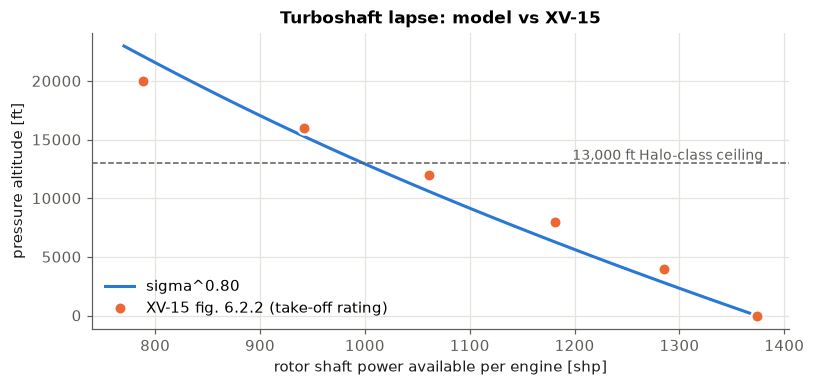

In [56]:
n = fit_lapse_exponent()
model = [float(xv15_engine(n).power_available_W(asb.Atmosphere(altitude=h))) for h in data.altitude_power_m]
print(f"fitted lapse exponent n = {n:.3f}")
for h, p, m in zip(data.altitude_power_m, data.power_available_rotor_W, model):
    print(f"  {h / u.foot:6.0f} ft: digitized {p / u.hp:5.0f} shp, model {m / u.hp:5.0f} shp ({m / p - 1:+.1%})")
check("lapse within 6 % of the digitized curve to 20,000 ft",
      all(abs(m / p - 1) < 0.06 for m, p in zip(model, data.power_available_rotor_W)))
sigma_13kft = float(asb.Atmosphere(altitude=13000 * u.foot).density() / asb.Atmosphere(altitude=0).density())
print(f"power available at the 13,000 ft Halo-class ceiling: {sigma_13kft**n:.1%} of sea level")

h_ft = np.linspace(0, 23000, 60)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot([float(xv15_engine(n).power_available_W(asb.Atmosphere(altitude=h * u.foot))) / u.hp for h in h_ft], h_ft,
        color=blue, lw=2, label=f"sigma^{n:.2f}")
ax.plot([p / u.hp for p in data.power_available_rotor_W], [h / u.foot for h in data.altitude_power_m], "o", color=orange,
        ms=8, mec="white", mew=1.5, label="XV-15 fig. 6.2.2 (take-off rating)")
ax.axhline(13000, color=ink_muted, lw=1, ls="--")
ax.text(1380, 13300, "13,000 ft Halo-class ceiling", color=ink_muted, fontsize=9, ha="right")
ax.set(xlabel="rotor shaft power available per engine [shp]", ylabel="pressure altitude [ft]",
       title="Turboshaft lapse: model vs XV-15")
ax.legend(frameon=False, loc="lower left")
plt.tight_layout()
plt.show()

### 3. Hover: figure of merit and download

The XV-15 hover figure includes 7 % wing download and 0.93 transmission
efficiency; the power curve above is already rotor shaft power. The figure of
merit is calibrated so the sea-level hover weight uses exactly the power
available there. Every higher point is then a prediction from the lapse model
and the actuator disk. Each hover weight and the ceiling come from one
explicit Opti equality.

calibrated figure of merit: 0.670


     229 ft: figure  15578 lb, model  15578 lb (+0.0%)
    2214 ft: figure  14897 lb, model  14803 lb (-0.6%)
    4198 ft: figure  14225 lb, model  14056 lb (-1.2%)
    6183 ft: figure  13554 lb, model  13337 lb (-1.6%)
    8168 ft: figure  12882 lb, model  12646 lb (-1.8%)
   10153 ft: figure  12211 lb, model  11985 lb (-1.9%)
   20000 ft: figure   8850 lb, model   9118 lb (+3.0%)
PASS  sea-level hover weight reproduced (calibration point)
PASS  hover weights predicted within 5 % at every altitude


OGE hover ceiling at 13,000 lb: 7,141 ft (figure take-off line ~7,800 ft; SP-4517 8,650 ft)
PASS  hover ceiling within 1,000 ft of the 7,800-8,650 ft band
hover power, calibrated model / Tier 9 assumption = 1.33
PASS  Tier 9 hover power was optimistic by more than 20 %


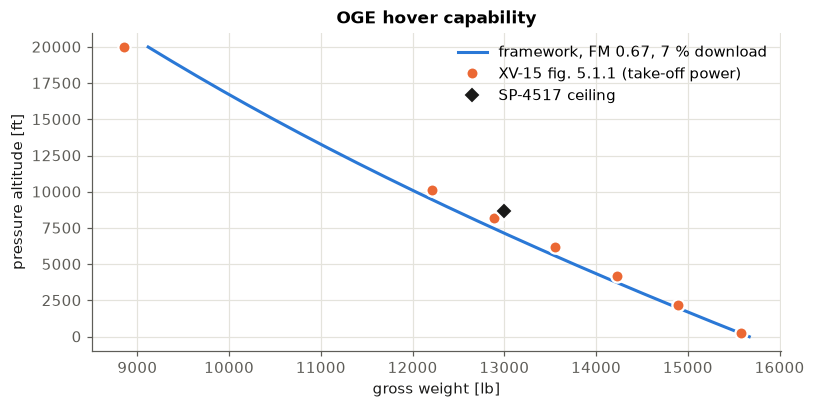

In [57]:
figure_of_merit = calibrate_figure_of_merit(n)
print(f"calibrated figure of merit: {figure_of_merit:.3f}")
predicted = [hover_mass_kg(h, figure_of_merit, n) for h in data.altitude_hover_m]
for h, m, p in zip(data.altitude_hover_m, data.mass_hover_kg, predicted):
    print(f"  {h / u.foot:6.0f} ft: figure {m / u.lbm:6.0f} lb, model {p / u.lbm:6.0f} lb ({p / m - 1:+.1%})")
check("sea-level hover weight reproduced (calibration point)", abs(predicted[0] / data.mass_hover_kg[0] - 1) < 1e-6)
check("hover weights predicted within 5 % at every altitude",
      all(abs(p / m - 1) < 0.05 for p, m in zip(predicted, data.mass_hover_kg)))
ceiling_ft = hover_ceiling_m(Xv15Reference().mass_design_kg, figure_of_merit, n) / u.foot
print(f"OGE hover ceiling at 13,000 lb: {ceiling_ft:,.0f} ft (figure take-off line ~7,800 ft; SP-4517 8,650 ft)")
check("hover ceiling within 1,000 ft of the 7,800-8,650 ft band", 6800 < ceiling_ft < 9650)
ratio = tier9_hover_power_ratio(figure_of_merit)
print(f"hover power, calibrated model / Tier 9 assumption = {ratio:.2f}")
check("Tier 9 hover power was optimistic by more than 20 %", ratio > 1.2)

alt_ft = np.linspace(0, 20000, 21)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot([hover_mass_kg(h * u.foot, figure_of_merit, n) / u.lbm for h in alt_ft], alt_ft, color=blue, lw=2,
        label=f"framework, FM {figure_of_merit:.2f}, 7 % download")
ax.plot([m / u.lbm for m in data.mass_hover_kg], [h / u.foot for h in data.altitude_hover_m], "o", color=orange, ms=8,
        mec="white", mew=1.5, label="XV-15 fig. 5.1.1 (take-off power)")
ax.plot([13000], [8650], "D", color=ink, ms=8, mec="white", mew=1.5, label="SP-4517 ceiling")
ax.set(xlabel="gross weight [lb]", ylabel="pressure altitude [ft]", title="OGE hover capability")
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

### 4. Part-power fuel use

AeroSandbox's turboshaft efficiency fit includes a part-power knockdown from
Geiss (2020). The engine uses it as a ratio, so its own full-power efficiency
stays an explicit input. Throttle is shaft power over power available; for the
LTC1K-4K the maximum is the contingency rating.

In [58]:
rows = part_power_sfc_ratios()
for throttle, published, model in rows:
    print(f"  throttle {throttle:.3f}: published sfc ratio {published:.3f}, model {model:.3f}")
check("knockdown matches the four LTC1K-4K ratings within 2 %", all(abs(m / p - 1) < 0.02 for _, p, m in rows))
check("knockdown is 1 at full throttle", abs(rows[0][2] - 1) < 1e-12)
eta = thermal_efficiency_from_sfc(0.564)
print(f"LTC1K-4K thermal efficiency at contingency: {eta:.3f} (Tier 1 default 0.30)")
check("published sfc implies 0.24 thermal efficiency (a 1950s-design engine)", abs(eta - 0.244) < 0.002)

  throttle 1.000: published sfc ratio 1.000, model 1.000
  throttle 0.860: published sfc ratio 1.035, model 1.039
  throttle 0.777: published sfc ratio 1.066, model 1.065
  throttle 0.694: published sfc ratio 1.103, model 1.096
PASS  knockdown matches the four LTC1K-4K ratings within 2 %
PASS  knockdown is 1 at full throttle
LTC1K-4K thermal efficiency at contingency: 0.244 (Tier 1 default 0.30)
PASS  published sfc implies 0.24 thermal efficiency (a 1950s-design engine)


## 12. Hot and high

*From `tier16_hot_high/hot_high_verification.ipynb`.*

In [59]:
import sys
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from aircraft_closure.powertrain.components.turboshaft import DensityTemperatureLapse, density_sea_level_kg_m3
from examples.halo_sizing import HaloRequirements, requirements_tier12b, soc_emergency_floor, solve_halo_sizing
from examples.xv15_hot_day import (Xv15HotDayData, hot_atmosphere, hover_mass_kg, temperature_offset_K,
                                   xv15_engine_hot, xv15_lapse_model)
from examples.xv15_performance import Xv15PowerData, calibrate_figure_of_merit, fit_lapse_exponent

check_log = globals().get("check_log", [])


def check(name, passed):
    # Record and print one named verification.
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

# Plan 022 made the 780 kg equivalent-circuit pack the reference; this notebook keeps reproducing its own tier
# (900 kg, constant-OCV battery).
from functools import partial
from examples.halo_sizing import HaloAssumptions as _HaloAssumptions, HaloRequirements as _HaloRequirements
from examples.halo_sizing import solve_halo_sizing as _solve_halo_sizing
HaloAssumptions = partial(_HaloAssumptions, drag_corrections=False, redundancy=False, machine_mass_model="torque_density", gearbox_stages=False,
                          battery_model="constant", wing_weight_model="raymer",
                          aerodynamics_model="simple", thermal_model=False)
HaloRequirements = partial(_HaloRequirements, mass_payload_kg=900.0)
solve_halo_sizing = partial(_solve_halo_sizing, requirements=HaloRequirements(), assumptions=HaloAssumptions())

### 1. The hot-day atmosphere

On a "95 F" day the ambient temperature is 95 F at every pressure altitude, so the offset from ISA grows with
altitude. The offset is taken from AeroSandbox's own standard atmosphere (its smooth ISA differs from the
tabulated one by about 0.3 K at 4,000 ft), so the point is exactly 308.15 K.

In [60]:
altitude_m = 4000 * u.foot
offset_K = float(temperature_offset_K(altitude_m, 308.15))
standard, hot = asb.Atmosphere(altitude=altitude_m), asb.Atmosphere(altitude=altitude_m, temperature_deviation=offset_K)
print(f"4,000 ft: ISA {float(standard.temperature()) - 273.15:.2f} C, 95 F = 35.00 C -> offset ISA + {offset_K:.2f} K")
print(f"density ratio: standard {float(standard.density() / density_sea_level_kg_m3):.4f}, "
      f"hot {float(hot.density() / density_sea_level_kg_m3):.4f}")
check("4k/95 offset is ISA + 27.7 K", abs(offset_K - 27.66) < 0.01)
check("the offset leaves pressure unchanged (pressure altitude)", abs(float(hot.pressure() / standard.pressure()) - 1) < 1e-12)
check("hot-day density = standard x T_ISA / T", abs(float(hot.density() / standard.density())
                                                   - float(standard.temperature() / hot.temperature())) < 1e-9)

4,000 ft: ISA 7.34 C, 95 F = 35.00 C -> offset ISA + 27.66 K
density ratio: standard 0.8873, hot 0.8076
PASS  4k/95 offset is ISA + 27.7 K
PASS  the offset leaves pressure unchanged (pressure altitude)
PASS  hot-day density = standard x T_ISA / T


### 2. Turboshaft temperature lapse, fitted to the XV-15 95 F curve

Digitized 95 F take-off power (rotor shaft hp per engine). The same procedure re-reads the Tier 10b
standard-day curve within 7 shp, so the accuracy is about +/- 10 shp (+/- 15 shp at 12,000 ft, where the dashed
line runs into its label). The curve ends near 13,000 ft.

**Fit.** At one pressure altitude, density scales as 1/T. The model therefore gives
P_95F / P_std = (T / T_ISA)^-(n + m), and n + m is fitted to the paired curves at 0, 4,000, 8,000 and
12,000 ft. This is a data-to-data fit, so the error of the standard-day lapse does not enter it.

n = 0.797 (Tier 10b), m = 2.486, n + m = 3.283
 altitude  ISA+dT  P_95F/P_std data  model   residual
       0    20.0             0.803   0.802    -0.1%
    4000    27.7             0.732   0.734    +0.3%
    8000    35.3             0.670   0.670    +0.1%
   12000    43.3             0.610   0.609    -0.2%

 altitude  digitized  model   residual   (95 F power available)
       0       1103   1102    -0.1%
    2000       1021   1006    -1.5%
    4000        941    917    -2.5%
    6000        864    835    -3.3%
    8000        791    759    -4.0%
   10000        720    689    -4.4%
   12000        647    623    -3.7%
PASS  temperature exponent is physical (2 < m < 3)
PASS  paired 95 F / standard ratios fitted within 1.5 %
PASS  95 F power available within 5 % at every digitized altitude (includes the Tier 10b lapse error)
PASS  standard day reproduces Tier 10b sigma^n exactly


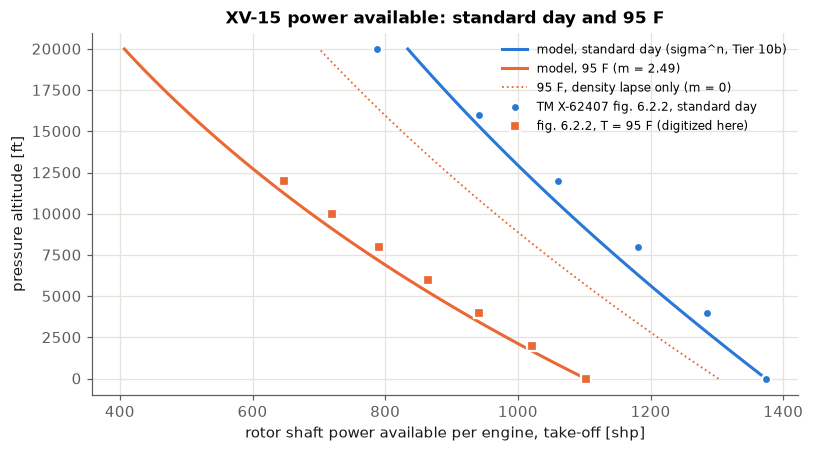

In [61]:
data, standard_data = Xv15HotDayData(), Xv15PowerData()
n = fit_lapse_exponent()
model = xv15_lapse_model(n)
m = model.lapse_exponent_temperature
engine = xv15_engine_hot(model)
print(f"n = {n:.3f} (Tier 10b), m = {m:.3f}, n + m = {n + m:.3f}")
hot_power = dict(zip(data.altitude_power_m, data.power_available_rotor_W))
print(" altitude  ISA+dT  P_95F/P_std data  model   residual")
pair_residuals = []
for h, p in zip(standard_data.altitude_power_m, standard_data.power_available_rotor_W):
    if h in hot_power:
        a = hot_atmosphere(h)
        theta = float(a.temperature() / (a.temperature() - a.temperature_deviation))
        ratio_model, ratio_data = theta**-(n + m), hot_power[h] / p
        pair_residuals.append(ratio_model / ratio_data - 1)
        print(f"{h / u.foot:8.0f}  {float(a.temperature_deviation):6.1f}  {ratio_data:16.3f}  {ratio_model:6.3f}  {pair_residuals[-1]:+7.1%}")
print("\n altitude  digitized  model   residual   (95 F power available)")
power_residuals = []
for h, p in zip(data.altitude_power_m, data.power_available_rotor_W):
    p_model = float(engine.power_available_W(hot_atmosphere(h)))
    power_residuals.append(p_model / p - 1)
    print(f"{h / u.foot:8.0f}  {p / u.hp:9.0f}  {p_model / u.hp:5.0f}  {power_residuals[-1]:+7.1%}")
check("temperature exponent is physical (2 < m < 3)", 2 < m < 3)
check("paired 95 F / standard ratios fitted within 1.5 %", max(abs(r) for r in pair_residuals) < 0.015)
check("95 F power available within 5 % at every digitized altitude (includes the Tier 10b lapse error)",
      max(abs(r) for r in power_residuals) < 0.05)
check("standard day reproduces Tier 10b sigma^n exactly", all(
    float(engine.power_available_W(asb.Atmosphere(altitude=h))) == float(
        standard_data.power_available_rotor_W[0] * (asb.Atmosphere(altitude=h).density() / density_sea_level_kg_m3)**n)
    for h in standard_data.altitude_power_m))

h_plot = np.linspace(0, 20000, 81) * u.foot
density_only = DensityTemperatureLapse(n, 0.0)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot([float(engine.power_available_W(asb.Atmosphere(altitude=h))) / u.hp for h in h_plot], h_plot / u.foot,
        color=blue, lw=2, label="model, standard day (sigma^n, Tier 10b)")
ax.plot([float(engine.power_available_W(hot_atmosphere(h))) / u.hp for h in h_plot], h_plot / u.foot,
        color=orange, lw=2, label=f"model, 95 F (m = {m:.2f})")
ax.plot([standard_data.power_available_rotor_W[0] * float(density_only.power_ratio(hot_atmosphere(h))) / u.hp
         for h in h_plot], h_plot / u.foot, color=orange, lw=1.2, ls=":", label="95 F, density lapse only (m = 0)")
ax.plot(np.array(standard_data.power_available_rotor_W) / u.hp, np.array(standard_data.altitude_power_m) / u.foot,
        "o", color=blue, ms=6, mec="white", mew=1.5, label="TM X-62407 fig. 6.2.2, standard day")
ax.plot(np.array(data.power_available_rotor_W) / u.hp, np.array(data.altitude_power_m) / u.foot,
        "s", color=orange, ms=6, mec="white", mew=1.5, label="fig. 6.2.2, T = 95 F (digitized here)")
ax.set(xlabel="rotor shaft power available per engine, take-off [shp]", ylabel="pressure altitude [ft]",
       title="XV-15 power available: standard day and 95 F")
ax.legend(frameon=False, fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

**Reading.** At constant pressure altitude, power falls as (T/T_ISA)^-3.3, about 1.1 % per kelvin. Density
alone (the dotted line) would explain about a quarter of the hot-day loss. The rest is the temperature limit of
the turbine. The temperature term is fitted on the take-off rating only.

### 3. Validation: predicting the 95 F hover weights

This is a prediction, not a fit. It uses the Tier 10b figure of merit, calibrated on the standard day at sea
level, together with the hot-day density at the rotor and the hot-day power available. The comparison is with
fig. 5.1.2's left twin-engine line, the counterpart of the fig. 5.1.1 line that Tier 10b took as take-off
power. The same procedure re-reads that fig. 5.1.1 line within 100 lb.

figure of merit 0.670 (Tier 10b, standard-day sea-level calibration)
 altitude   figure   predicted  error
     229    13339      13102   -1.8%
    2000    12445      12149   -2.4%
    4000    11442      11146   -2.6%
    6000    10458      10212   -2.4%
    8000     9546       9343   -2.1%
   10000     8708       8534   -2.0%
   12000     7902       7780   -1.5%
   14000     7046       7078   +0.5%  (above the 95 F power curve: lapse extrapolated)
   16000     6248       6424   +2.8%  (above the 95 F power curve: lapse extrapolated)
   18000     5572       5816   +4.4%  (above the 95 F power curve: lapse extrapolated)
PASS  95 F hover weights predicted within 3 % up to 12,000 ft
PASS  and within 5 % to 18,000 ft (extrapolated lapse)
4,000 ft: standard 14,129 lb, 95 F 11,146 lb (-21.1%)
PASS  the 4k/95 day costs the XV-15 more than 10 % of hover weight


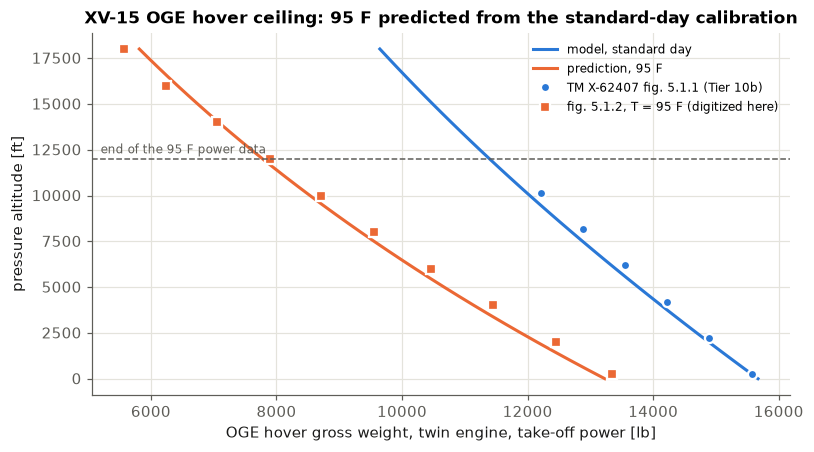

In [62]:
figure_of_merit = calibrate_figure_of_merit(n)
print(f"figure of merit {figure_of_merit:.3f} (Tier 10b, standard-day sea-level calibration)")
print(" altitude   figure   predicted  error")
errors = []
for h, mass in zip(data.altitude_hover_m, data.mass_hover_kg):
    predicted = hover_mass_kg(hot_atmosphere(h), figure_of_merit, model)
    errors.append((h, predicted / mass - 1, predicted))
    note = "" if h <= data.altitude_power_data_max_m + 1 else "  (above the 95 F power curve: lapse extrapolated)"
    print(f"{h / u.foot:8.0f}  {mass / u.lbm:7.0f}  {predicted / u.lbm:9.0f}  {errors[-1][1]:+6.1%}{note}")
inside = [e for h, e, _ in errors if h <= data.altitude_power_data_max_m + 1]
outside = [e for h, e, _ in errors if h > data.altitude_power_data_max_m + 1]
check("95 F hover weights predicted within 3 % up to 12,000 ft", max(abs(e) for e in inside) < 0.03)
check("and within 5 % to 18,000 ft (extrapolated lapse)", max(abs(e) for e in outside) < 0.05)
standard_4k = hover_mass_kg(asb.Atmosphere(altitude=4000 * u.foot), figure_of_merit, model)
hot_4k = hover_mass_kg(hot_atmosphere(4000 * u.foot), figure_of_merit, model)
print(f"4,000 ft: standard {standard_4k / u.lbm:,.0f} lb, 95 F {hot_4k / u.lbm:,.0f} lb ({hot_4k / standard_4k - 1:+.1%})")
check("the 4k/95 day costs the XV-15 more than 10 % of hover weight", hot_4k < 0.9 * standard_4k)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
h_hover = np.linspace(0, 18000, 37) * u.foot
ax.plot([hover_mass_kg(asb.Atmosphere(altitude=h), figure_of_merit, model) / u.lbm for h in h_hover],
        h_hover / u.foot, color=blue, lw=2, label="model, standard day")
ax.plot([hover_mass_kg(hot_atmosphere(h), figure_of_merit, model) / u.lbm for h in h_hover],
        h_hover / u.foot, color=orange, lw=2, label="prediction, 95 F")
ax.plot(np.array(standard_data.mass_hover_kg[:-1]) / u.lbm, np.array(standard_data.altitude_hover_m[:-1]) / u.foot,
        "o", color=blue, ms=6, mec="white", mew=1.5, label="TM X-62407 fig. 5.1.1 (Tier 10b)")
ax.plot(np.array(data.mass_hover_kg) / u.lbm, np.array(data.altitude_hover_m) / u.foot,
        "s", color=orange, ms=6, mec="white", mew=1.5, label="fig. 5.1.2, T = 95 F (digitized here)")
ax.axhline(data.altitude_power_data_max_m / u.foot, color=ink_muted, lw=1, ls="--")
ax.text(5200, data.altitude_power_data_max_m / u.foot + 300, "end of the 95 F power data", color=ink_muted, fontsize=8)
ax.set(xlabel="OGE hover gross weight, twin engine, take-off power [lb]", ylabel="pressure altitude [ft]",
       title="XV-15 OGE hover ceiling: 95 F predicted from the standard-day calibration")
ax.legend(frameon=False, fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

## Summary

In [63]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} of {len(check_log)} checks passed")
for name in failed:
    print("FAILED:", name)

231 of 231 checks passed
